# Prognozowanie ceny Bitcoina z wykorzystaniem danych on-chain
## Modele: ARIMA · ARIMAX · LSTM · BiLSTM

**Cel projektu:** Porównanie skuteczności klasycznych modeli szeregów czasowych (ARIMA/ARIMAX)
i głębokich sieci neuronowych (LSTM, BiLSTM) w prognozowaniu ceny BTC przy użyciu danych on-chain.

| Model   | Opis |
|---------|------|
| **ARIMA**   | AutoRegressive Integrated Moving Average — klasyczny model szeregów czasowych |
| **ARIMAX**  | ARIMA z 9 zmiennymi egzogenicznymi on-chain (aktywne adresy, stablecoiny, hash-rate…) |
| **LSTM**    | Long Short-Term Memory — sieć neuronowa ucząca się długoterminowych wzorców |
| **BiLSTM**  | Bidirectional LSTM — LSTM przetwarzający sekwencje w obu kierunkach |

---

**Dane treningowe:** do 2025-05-31 (włącznie)
**Dane testowe:** od 2025-06-01 (modele nigdy ich nie widziały)
**Horyzonty prognoz:** 1 tydzień · 1 miesiąc · 1 kwartał · 2 kwartały · 1 rok

**Dwa tryby prognozowania:**
- **Tryb 1 – Walk-forward:** co dzień modele otrzymują *prawdziwą cenę* poprzedniego dnia (jednokrokowe prognozy, bardziej precyzyjne)
- **Tryb 2 – Czyste prognozowanie** *(priorytetowy)*: od 2025-06-01 modele *nie otrzymują* żadnej aktualizacji ceny i prognozują N dni naprzód z jednego punktu (realistyczny scenariusz decyzyjny)

In [106]:
import warnings, sys
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

MODEL_COLORS = {
    'True':   '#111111',
    'ARIMA':  '#1565C0',
    'ARIMAX': '#2E7D32',
    'LSTM':   '#C62828',
    'BiLSTM': '#E65100',
}
HORIZONS = {
    '1 tydzien':  7,
    '1 miesiac':  30,
    '1 kwartal':  90,
    '2 kwartaly': 180,
    '1 rok':      365,
}
print("Biblioteki wczytane pomyślnie.")
print(f"TensorFlow w wersji: {tf.__version__}")

Biblioteki wczytane pomyślnie.
TensorFlow w wersji: 2.16.2


## 1. Wczytywanie danych

Dane pochodzą z automatycznego pipeline'u (`main.py`), który pobiera i scala:

| Źródło | Dane |
|--------|------|
| **Yahoo Finance** | Dzienna cena zamknięcia BTC/USD |
| **Blockchain.com API** | Liczba transakcji, hash-rate, wolumen, unikalne adresy |
| **CoinMetrics Community** | Aktywne adresy dziennie |
| **DefiLlama** | Kapitalizacja rynkowa stablecoinów |
| **mempool.space** | Dane sieci Lightning Network |

Pipeline zapisuje gotowy zbiór w `data/processed/bitcoin_final.csv`.

In [107]:
df = pd.read_csv(
    '../data/processed/bitcoin_final.csv',
    parse_dates=['date'],
    index_col='date'
)
df = df.sort_index()

# Wymus ciagly dzienny indeks (wypelnia ewentualne luki interpolacja)
full_idx = pd.date_range(start=df.index[0], end=df.index[-1], freq='D')
df = df.reindex(full_idx).interpolate(method='linear')
df.index.freq = pd.tseries.frequencies.to_offset('D')

print(f"Zakres dat:        {df.index.min().date()} → {df.index.max().date()}")
print(f"Liczba rekordów:   {len(df):,} (wierszy)")
print(f"Liczba kolumn:     {len(df.columns)}")
print(f"Braki danych:      {df.isnull().sum().sum()} (po uzupełnieniu interpolacją liniową)")
# Mapowanie nazw kolumn CSV -> czytelne polskie nazwy (używane w podglądach i tabelach)
DISPLAY_NAMES = {
    'price':                            'Cena BTC/USD',
    'n-transactions':                   'Liczba transakcji on-chain',
    'hash-rate':                        'Hash-rate sieci (TH/s)',
    'active_addresses':                 'Aktywne adresy dziennie',
    'stablecoin_market_cap':            'Kapitalizacja stablecoinów (USD)',
    'estimated-transaction-volume-usd': 'Wolumen transakcji (USD)',
    'ln_total_capacity_btc':            'Pojemność Lightning Network (BTC)',
    'whale_proxy_avg_tx':               'Proxy wielorybów (śr. wartość tx)',
    'hodl_velocity':                    'HODL Velocity',
    'ssr_ratio':                        'Stablecoin Supply Ratio (SSR)',
    'n-unique-addresses':               'Unikalne adresy',
}

preview_cols = [c for c in ['price', 'n-transactions', 'hash-rate', 'active_addresses', 'stablecoin_market_cap'] if c in df.columns]
df[preview_cols].rename(columns=DISPLAY_NAMES).tail(5)

Zakres dat:        2021-06-06 → 2026-05-05
Liczba rekordów:   1,795 (wierszy)
Liczba kolumn:     28
Braki danych:      0 (po uzupełnieniu interpolacją liniową)


,Cena BTC/USD,Liczba transakcji on-chain,Hash-rate sieci (TH/s),Aktywne adresy dziennie,Kapitalizacja stablecoinów (USD)
2026-05-01,78179.000000,566274.0,9.369236e+08,751425,3.186106e+11
2026-05-02,78657.250000,566274.0,9.369236e+08,620486,3.188399e+11
2026-05-03,78538.226562,566274.0,9.369236e+08,583469,3.198455e+11
2026-05-04,79827.906250,566274.0,9.369236e+08,722079,3.192520e+11
2026-05-05,80927.054688,566274.0,9.369236e+08,721256,3.206798e+11


### Opis zmiennych (kolumny zbioru danych)

| Nazwa kolumny (CSV) | Wyświetlana nazwa | Opis |
|---------------------|-------------------|------|
| `price` | **Cena BTC/USD** | Dzienna cena zamknięcia Bitcoin w dolarach — zmienna celu wszystkich modeli |
| `n-transactions` | **Liczba transakcji on-chain** | Całkowita liczba potwierdzonych transakcji w sieci Bitcoin w ciągu doby — miara aktywności sieci |
| `hash-rate` | **Hash-rate sieci (TH/s)** | Łączna moc obliczeniowa górników (terahaszów/s) — proxy bezpieczeństwa sieci i zaufania górników |
| `estimated-transaction-volume-usd` | **Wolumen transakcji (USD)** | Szacowana łączna wartość przesyłów on-chain w dolarach — mierzy wolumen ekonomiczny, nie spekulacyjny |
| `n-unique-addresses` | **Unikalne adresy** | Liczba unikalnych adresów BTC uczestniczących w transakcjach danego dnia |
| `active_addresses` | **Aktywne adresy dziennie** | Liczba aktywnych adresów (źródło: CoinMetrics) — szerszy wskaźnik adopcji |
| `stablecoin_market_cap` | **Kapitalizacja stablecoinów (USD)** | Łączna wartość rynkowa głównych stablecoinów — proxy gotówki gotowej do wejścia w BTC |
| `ln_total_capacity_btc` | **Pojemność Lightning Network (BTC)** | Całkowita pojemność kanałów Lightning Network — wskaźnik adopcji warstwy 2 |
| `whale_proxy_avg_tx` | **Proxy wielorybów (śr. wartość tx)** | Średnia wartość pojedynczej transakcji on-chain — wysoka wartość sygnalizuje aktywność dużych graczy |
| `hodl_velocity` | **HODL Velocity** | Stosunek dziennego wolumenu do kapitalizacji; niska wartość = posiadacze nie sprzedają (silny HODLing) |
| `ssr_ratio` | **Stablecoin Supply Ratio (SSR)** | Kapitalizacja BTC / kapitalizacja stablecoinów; niskie SSR = duży potencjał kupna stablecoinami |

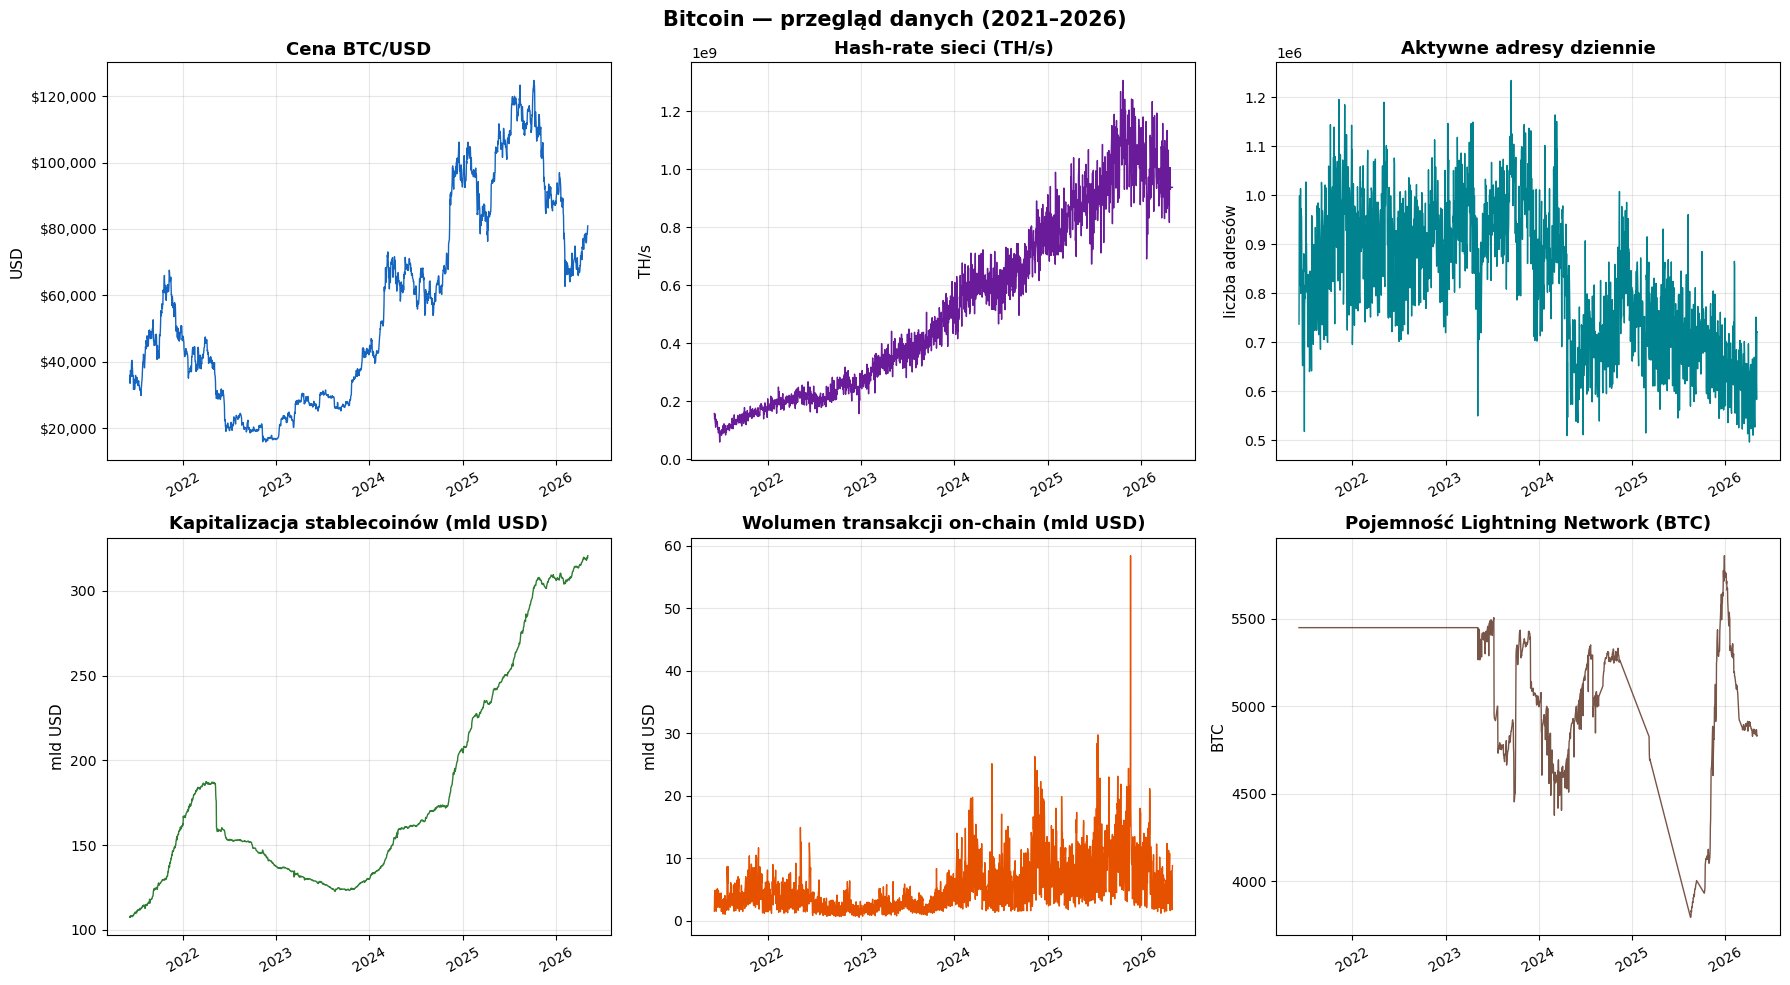

In [108]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bitcoin — przegląd danych (2021–2026)', fontsize=15, fontweight='bold')

panels = [
    ('price',                         'Cena BTC/USD',                  '#1565C0', None),
    ('hash-rate',                        'Hash-rate sieci (TH/s)',                 '#6A1B9A', None),
    ('active_addresses',                 'Aktywne adresy dziennie',               '#00838F', None),
    ('stablecoin_market_cap',            'Kapitalizacja stablecoinów (mld USD)',   '#2E7D32', 1e9),
    ('estimated-transaction-volume-usd', 'Wolumen transakcji on-chain (mld USD)', '#E65100', 1e9),
    ('ln_total_capacity_btc',            'Pojemność Lightning Network (BTC)',      '#795548', None),
]

for ax, (col, title, color, scale) in zip(axes.flatten(), panels):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    vals = df[col] / scale if scale else df[col]
    ax.plot(df.index, vals, color=color, linewidth=1.0)
    ax.set_title(title, fontweight='bold')
    # Jednostki osi Y zależne od kolumny
    unit_map = {
        'price':                            'USD',
        'hash-rate':                        'TH/s',
        'active_addresses':                 'liczba adresów',
        'stablecoin_market_cap':            'mld USD',
        'estimated-transaction-volume-usd': 'mld USD',
        'ln_total_capacity_btc':            'BTC',
    }
    ax.set_ylabel(unit_map.get(col, ''))
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30)
    if col == 'price':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../data/processed/eda_overview.png', bbox_inches='tight')
plt.show()

## 1b. Analiza statystyczna — log-zwroty i macierz korelacji

Przed modelowaniem warto zbadać **strukturę statystyczną danych**:

- **Log-zwroty** (logarytmiczne stopy zwrotu) są standardowym narzędziem analizy szeregów finansowych — mają rozkład zbliżony do normalnego i są stacjonarne
- **Macierz korelacji** pokazuje, które zmienne on-chain współzmieniają się z ceną BTC — to bezpośrednia wskazówka, które metryki mają potencjał predykcyjny w modelu ARIMAX
- **ACF / PACF** log-zwrotów służą do doboru rzędów `q` i `p` w modelu ARIMA

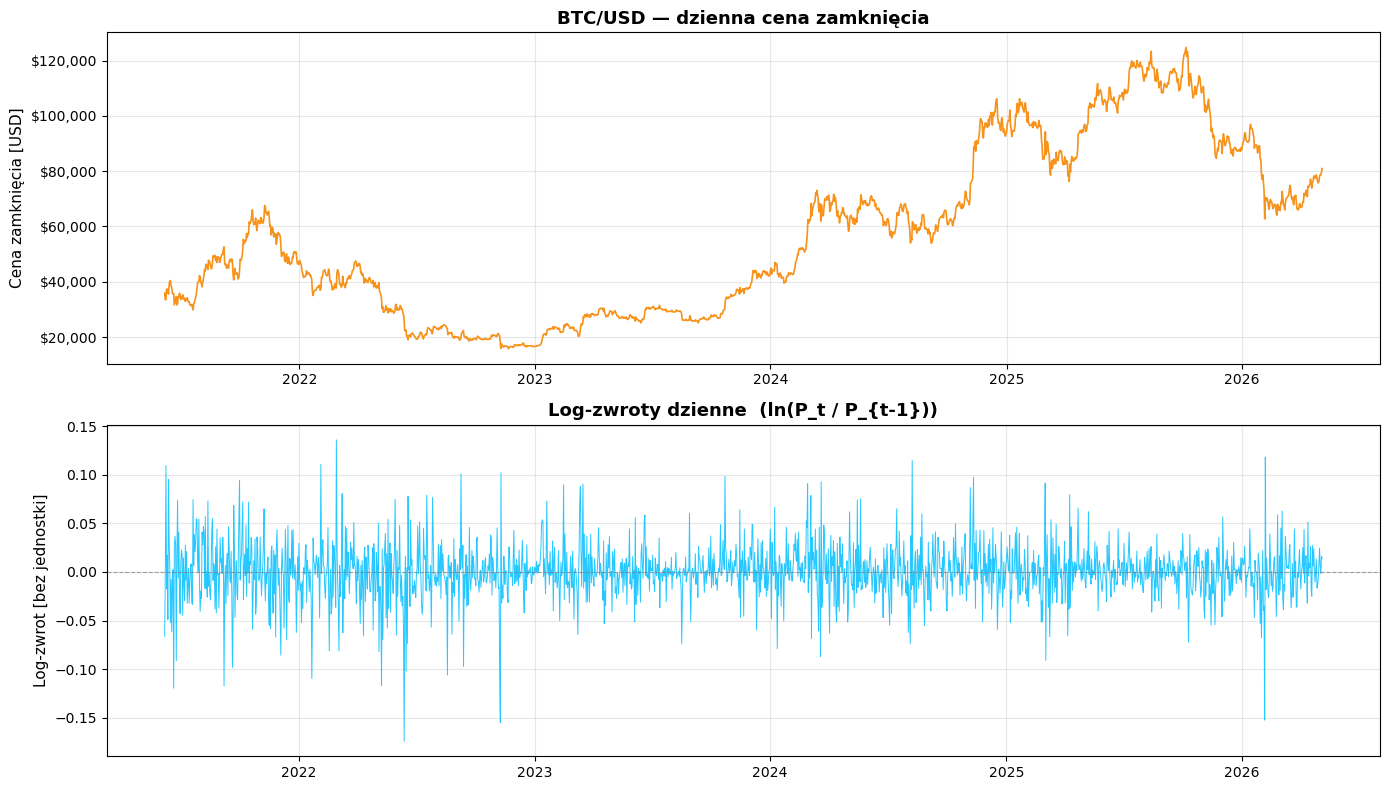

Statystyki log-zwrotów dziennych BTC:
  Średnia dzienna stopa zwrotu: +0.0454%
  Odch. std (zmienność):        2.8362%  (~54.2% rocznie)
  Min / Max:                    -17.41% / 13.58%
  Skośność:                     -0.1940  (0 = symetryczny)
  Kurtoza (excess):             3.9602  (0 = normalny; >0 = grube ogony)


In [109]:
# ── Log-zwroty dzienne BTC ────────────────────────────────────────────────────
log_ret = np.log(df['price'] / df['price'].shift(1)).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Górny panel: cena BTC
axes[0].plot(df.index, df['price'], color='#F7931A', linewidth=1.2)
axes[0].set_title('BTC/USD — dzienna cena zamknięcia', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cena zamknięcia [USD]')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

# Dolny panel: log-zwroty
axes[1].plot(log_ret.index, log_ret, color='#00BFFF', linewidth=0.7, alpha=0.85)
axes[1].axhline(0, color='white' if plt.rcParams.get('figure.facecolor','white')=='black' else 'gray',
                linewidth=0.8, linestyle='--', alpha=0.7)
axes[1].set_title('Log-zwroty dzienne  (ln(P_t / P_{t-1}))', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log-zwrot [bez jednostki]')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../data/processed/btc_logret.png', bbox_inches='tight', dpi=120)
plt.show()

# Podstawowe statystyki log-zwrotów
print('Statystyki log-zwrotów dziennych BTC:')
print(f'  Średnia dzienna stopa zwrotu: {log_ret.mean()*100:+.4f}%')
print(f'  Odch. std (zmienność):        {log_ret.std()*100:.4f}%  (~{log_ret.std()*100*np.sqrt(365):.1f}% rocznie)')
print(f'  Min / Max:                    {log_ret.min()*100:.2f}% / {log_ret.max()*100:.2f}%')
print(f'  Skośność:                     {log_ret.skew():.4f}  (0 = symetryczny)')
print(f'  Kurtoza (excess):             {log_ret.kurt():.4f}  (0 = normalny; >0 = grube ogony)')


### Macierz korelacji zmiennych on-chain z ceną BTC

Kolory wskazują kierunek i siłę zależności liniowej:
- **Ciemny czerwony (blisko +1)** — silna korelacja dodatnia: wzrost zmiennej towarzyszy wzrostowi ceny
- **Ciemny niebieski (blisko −1)** — silna korelacja ujemna
- **Blisko 0** — brak liniowej zależności

> **Uwaga:** korelacja ≠ przyczynowość. Wysoka korelacja nie oznacza, że zmienna *powoduje* ruch ceny.

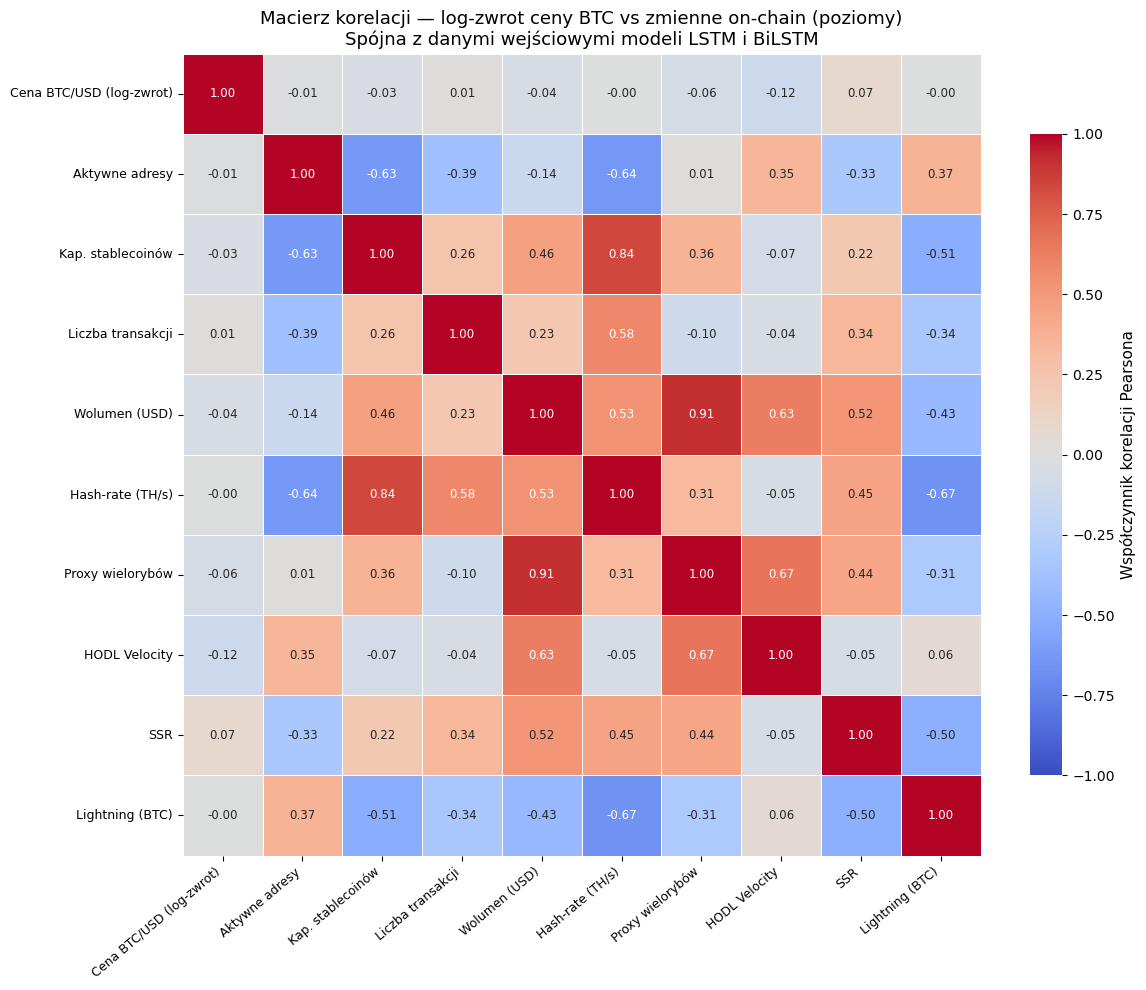

Korelacja log-zwrotu ceny BTC ze zmiennymi on-chain (poziomy):
(spójne z data_lstm — price jako log-zwrot, reszta jako surowe wartości)
  Zmienna                                 Korelacja  Interpretacja
  ────────────────────────────────────────────────────────────────────────
  HODL Velocity                             -0.1241  słaba / brak
  SSR                                       +0.0722  słaba / brak
  Proxy wielorybów                          -0.0607  słaba / brak
  Wolumen (USD)                             -0.0432  słaba / brak
  Kap. stablecoinów                         -0.0334  słaba / brak
  Liczba transakcji                         +0.0110  słaba / brak
  Aktywne adresy                            -0.0091  słaba / brak
  Lightning (BTC)                           -0.0040  słaba / brak
  Hash-rate (TH/s)                          -0.0010  słaba / brak


In [110]:
import seaborn as sns

CORR_COLS = ['price'] + [c for c in EXOG_COLS if c in df.columns]

# price → log-zwrot, pozostałe → poziomy (spójne z data_lstm)
corr_data = df[CORR_COLS].copy().dropna()
corr_data['price'] = np.log(corr_data['price'] / corr_data['price'].shift(1))
corr_data = corr_data.dropna()
corr_matrix = corr_data.corr()

CORR_LABELS = {
    'price':                            'Cena BTC/USD (log-zwrot)',
    'active_addresses':                 'Aktywne adresy',
    'stablecoin_market_cap':            'Kap. stablecoinów',
    'n-transactions':                   'Liczba transakcji',
    'estimated-transaction-volume-usd': 'Wolumen (USD)',
    'hash-rate':                        'Hash-rate (TH/s)',
    'whale_proxy_avg_tx':               'Proxy wielorybów',
    'hodl_velocity':                    'HODL Velocity',
    'ssr_ratio':                        'SSR',
    'ln_total_capacity_btc':            'Lightning (BTC)',
    'n-unique-addresses':               'Unikalne adresy',
}
corr_matrix.index   = [CORR_LABELS.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [CORR_LABELS.get(c, c) for c in corr_matrix.columns]

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1, center=0,
    annot_kws={'size': 8.5},
    cbar_kws={'label': 'Współczynnik korelacji Pearsona', 'shrink': 0.8},
)
plt.title(
    'Macierz korelacji — log-zwrot ceny BTC vs zmienne on-chain (poziomy)\n'
    'Spójna z danymi wejściowymi modeli LSTM i BiLSTM',
    fontsize=13
)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix_lstm_style.png', bbox_inches='tight', dpi=130)
plt.show()

price_corr = corr_matrix.loc['Cena BTC/USD (log-zwrot)'].drop('Cena BTC/USD (log-zwrot)').sort_values(key=abs, ascending=False)
print('Korelacja log-zwrotu ceny BTC ze zmiennymi on-chain (poziomy):')
print('(spójne z data_lstm — price jako log-zwrot, reszta jako surowe wartości)')
print(f'  {"Zmienna":<38} {"Korelacja":>10}  Interpretacja')
print('  ' + '─' * 72)
for name, val in price_corr.items():
    direction = 'dodatnia ↑' if val > 0.3 else ('ujemna ↓' if val < -0.3 else 'słaba / brak')
    print(f'  {name:<38} {val:>+10.4f}  {direction}')

### ACF i PACF log-zwrotów — diagnostyka opóźnień

Wykresy funkcji autokorelacji pomagają dobrać parametry `p` i `q` modelu ARIMA:

| Wykres | Parametr | Zasada |
|--------|----------|--------|
| **ACF** (Autocorrelation Function) | `q` — rząd MA | Liczba opóźnień wychodzących **poza** przedział ufności |
| **PACF** (Partial Autocorrelation) | `p` — rząd AR | Liczba opóźnień wychodzących **poza** przedział ufności |

Dla czystego *random walk* (idealny rynek efektywny) ani ACF, ani PACF nie powinny mieć istotnych opóźnień.

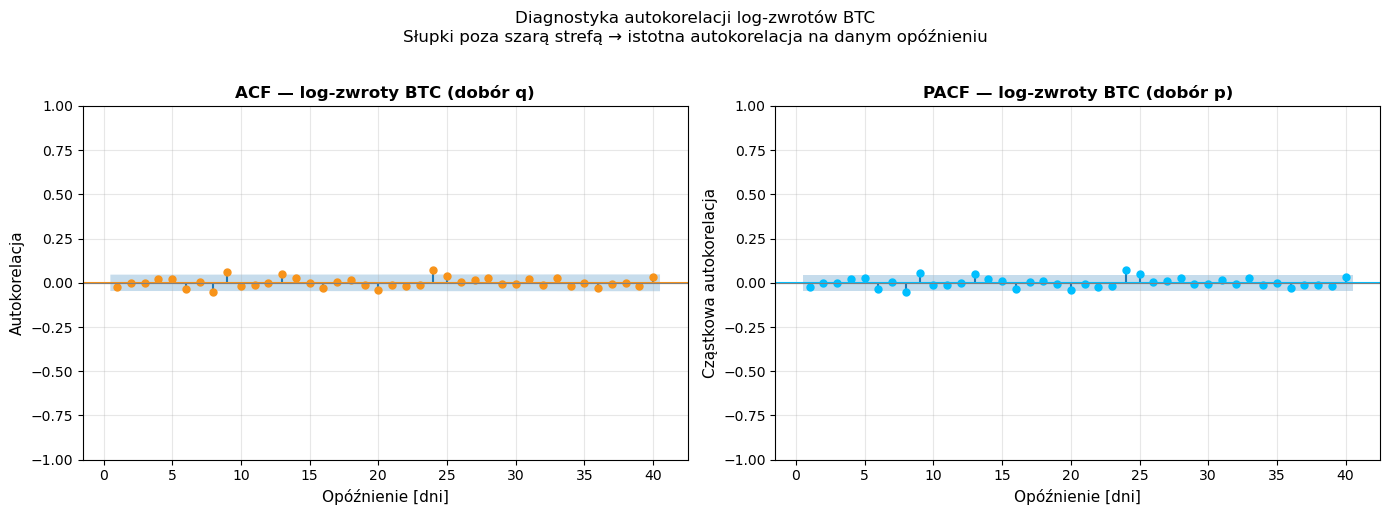

Interpretacja:
  Jeśli ACF i PACF są bliskie 0 dla lag>0 → szereg jest bliski białemu szumowi (random walk).
  Oznacza to, że ARIMA będzie miała trudności z trafnymi prognozami kierunkowymi.


In [111]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(log_ret, lags=40, ax=axes[0], alpha=0.05, color='#F7931A', zero=False)
axes[0].set_title('ACF — log-zwroty BTC (dobór q)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Opóźnienie [dni]')
axes[0].set_ylabel('Autokorelacja')
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].grid(True, alpha=0.3)

plot_pacf(log_ret, lags=40, ax=axes[1], alpha=0.05, color='#00BFFF', method='ywm', zero=False)
axes[1].set_title('PACF — log-zwroty BTC (dobór p)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Opóźnienie [dni]')
axes[1].set_ylabel('Cząstkowa autokorelacja')
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Diagnostyka autokorelacji log-zwrotów BTC\n'
             'Słupki poza szarą strefą → istotna autokorelacja na danym opóźnieniu',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/acf_pacf_logret.png', bbox_inches='tight', dpi=120)
plt.show()

print('Interpretacja:')
print('  Jeśli ACF i PACF są bliskie 0 dla lag>0 → szereg jest bliski białemu szumowi (random walk).')
print('  Oznacza to, że ARIMA będzie miała trudności z trafnymi prognozami kierunkowymi.')


## 2. Podział na zbiór treningowy i testowy

Punkt cięcia: **31 maja 2025**.

- Modele *trenowane* na danych do 2025-05-31 włącznie
- Dane *testowe* (od 2025-06-01) służą wyłącznie do oceny — modele ich nigdy nie widziały

Pozwala to na obiektywne porównanie prognoz dla horyzontów do 1 roku naprzód.

Zbiór treningowy:  2021-06-06 → 2025-05-31  (1456 dni)
Zbiór testowy:     2025-06-01 → 2026-05-05  (339 dni)


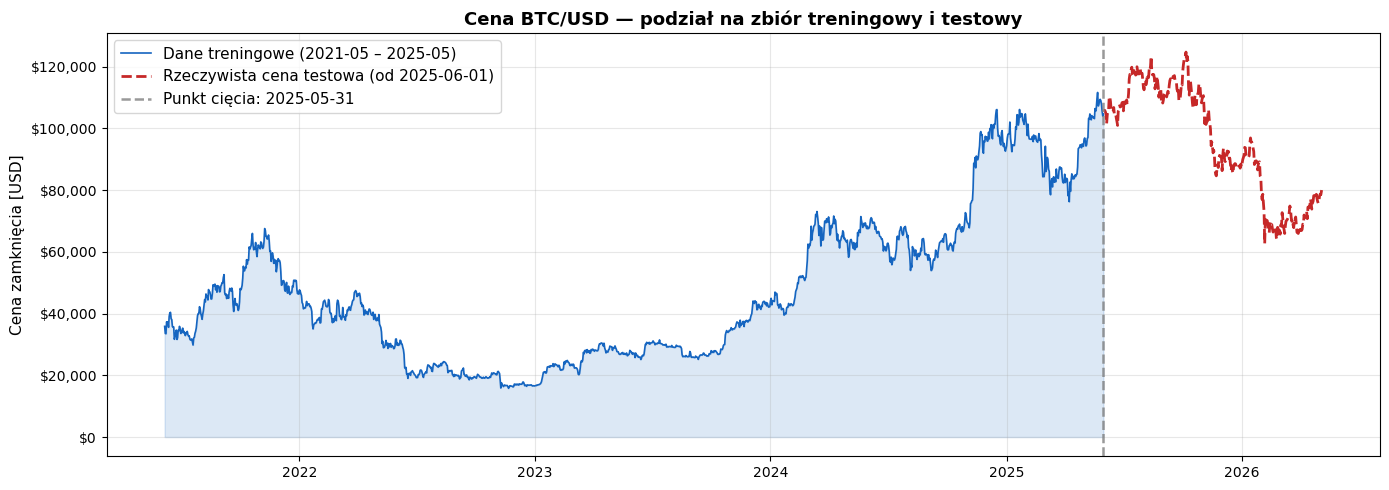

Ostatnia cena treningowa:  $104,638  (2025-05-31)
Pierwsza cena testowa:     $105,652  (2025-06-01)


In [112]:
TRAIN_END = pd.Timestamp('2025-05-31')

train = df[df.index <= TRAIN_END].copy()
test  = df[df.index >  TRAIN_END].copy()

print(f"Zbiór treningowy:  {train.index.min().date()} → {train.index.max().date()}  ({len(train)} dni)")
print(f"Zbiór testowy:     {test.index.min().date()} → {test.index.max().date()}  ({len(test)} dni)")

# Wizualizacja podzialu
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(train.index, train['price'], alpha=0.15, color='#1565C0')
ax.plot(train.index, train['price'], color='#1565C0', lw=1.2, label='Dane treningowe (2021-05 – 2025-05)')
ax.plot(test.index,  test['price'],  color='#C62828', lw=2.0, ls='--',
        label='Rzeczywista cena testowa (od 2025-06-01)')
ax.axvline(TRAIN_END, color='gray', ls='--', lw=1.8, alpha=0.8, label='Punkt cięcia: 2025-05-31')
ax.set_title('Cena BTC/USD — podział na zbiór treningowy i testowy', fontweight='bold')
ax.set_ylabel('Cena zamknięcia [USD]')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../data/processed/train_test_split.png', bbox_inches='tight')
plt.show()

train_price = train['price'].copy()
test_price  = test['price'].copy()
print(f"Ostatnia cena treningowa:  ${train_price.iloc[-1]:,.0f}  ({train_price.index[-1].date()})")
print(f"Pierwsza cena testowa:     ${test_price.iloc[0]:,.0f}  ({test_price.index[0].date()})")

## 3. Model ARIMA

**ARIMA(p, d, q)** — AutoRegressive Integrated Moving Average:
- **p** — rząd autoregresji: model używa *p* poprzednich wartości ceny
- **d** — stopień różnicowania: ile razy różnicować szereg, aby był stacjonarny
- **q** — rząd średniej kroczącej błędu

### Test stacjonarności ADF
Hipoteza zerowa: *szereg jest niestacjonarny* (ma pierwiastek jednostkowy).
Jeśli p-wartość > 0.05 → odrzucamy H0 → stosujemy differencing (d = 1).

### Dobór parametrów p, q
Przeszukujemy siatkę (p, q) ∈ {0..4}² i wybieramy model z **najniższym AIC**.

In [113]:
def adf_test(series, name=''):
    res = adfuller(series.dropna())
    ok = res[1] < 0.05
    print(f'Test ADF dla: {name}')
    print(f'  Statystyka testowa: {res[0]:.4f}  |  p-wartość: {res[1]:.6f}')
    print(f'  Wniosek:    {"✓ STACJONARNY — d=0 wystarczy" if ok else "✗ NIESTACJONARNY → stosujemy różnicowanie d=1"}')
    return ok

print('=== Test stacjonarności: cena BTC (poziomy) ===')
level_ok = adf_test(train_price, 'BTC Price')
print()
print('=== Test stacjonarności: pierwsza różnica ceny BTC ===')
diff_ok = adf_test(train_price.diff().dropna(), 'BTC diff(1)')
d_order = 0 if level_ok else 1
print(f'\n→ Przyjęty rząd różnicowania: d = {d_order}')

=== Test stacjonarności: cena BTC (poziomy) ===
Test ADF dla: BTC Price
  Statystyka testowa: -0.1368  |  p-wartość: 0.945644
  Wniosek:    ✗ NIESTACJONARNY → stosujemy różnicowanie d=1

=== Test stacjonarności: pierwsza różnica ceny BTC ===
Test ADF dla: BTC diff(1)
  Statystyka testowa: -9.4591  |  p-wartość: 0.000000
  Wniosek:    ✓ STACJONARNY — d=0 wystarczy

→ Przyjęty rząd różnicowania: d = 1


In [114]:
print(f'Przeszukiwanie siatki ARIMA(p,{d_order},q) — p,q ∈ [0..4]...')
best_aic   = np.inf
best_order = (2, d_order, 2)
aic_rows   = []

for p in range(5):
    for q in range(5):
        try:
            m = ARIMA(train_price, order=(p, d_order, q)).fit()
            aic_rows.append({'p': p, 'q': q, 'AIC': round(m.aic, 1), 'BIC': round(m.bic, 1)})
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d_order, q)
        except Exception:
            pass

aic_df = pd.DataFrame(aic_rows).sort_values('AIC').head(8).reset_index(drop=True)
print('Top 8 modeli ARIMA według kryterium AIC (im niższy, tym lepszy):')
print(aic_df.to_string(index=False))
print(f'\n→ Wybrany model: ARIMA{best_order}  (AIC = {best_aic:.1f})')

Przeszukiwanie siatki ARIMA(p,1,q) — p,q ∈ [0..4]...
Top 8 modeli ARIMA według kryterium AIC (im niższy, tym lepszy):
 p  q     AIC     BIC
 4  4 25382.1 25429.6
 3  4 25384.1 25426.4
 4  2 25385.2 25422.2
 3  2 25386.0 25417.7
 2  1 25386.7 25407.8
 2  2 25386.8 25413.2
 3  3 25388.5 25425.5
 0  1 25389.8 25400.4

→ Wybrany model: ARIMA(4, 1, 4)  (AIC = 25382.1)


In [115]:
print(f'Dopasowywanie modelu ARIMA{best_order} na {len(train_price)} dniach treningowych...')
arima_model = ARIMA(train_price, order=best_order).fit()
print(arima_model.summary())

Dopasowywanie modelu ARIMA(4, 1, 4) na 1456 dniach treningowych...
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                 1456
Model:                 ARIMA(4, 1, 4)   Log Likelihood              -12682.037
Date:                Sun, 24 May 2026   AIC                          25382.074
Time:                        19:56:17   BIC                          25429.619
Sample:                    06-06-2021   HQIC                         25399.813
                         - 05-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4390      0.102    -14.135      0.000      -1.638      -1.239
ar.L2         -1.1827      0.085    -13.912      0.000      -1.3

## 4. Model ARIMAX (z danymi on-chain)

ARIMAX rozszerza ARIMA o **egzogeniczne zmienne** (dane on-chain),
które dostarczają sieci zewnętrznego kontekstu makroekonomicznego.

**Ważne: lag = 1** — aby uniknąć *data leakage*, każda zmienna on-chain przesunięta jest o 1 dzień wstecz.
Oznacza to: do prognozowania ceny na dzień *T* używamy danych on-chain z dnia *T−1* (które są już znane).

### Zmienne egzogeniczne (9 metryk on-chain)

Każda zmienna jest **przesunięta o 1 dzień wstecz** (lag=1) — model widzi tylko dane dostępne w momencie prognozowania.

| Kolumna CSV | Wyświetlana nazwa | Rola w modelu |
|-------------|-------------------|---------------|
| `active_addresses` | **Aktywne adresy dziennie** | Bieżąca aktywność użytkowników sieci |
| `stablecoin_market_cap` | **Kapitalizacja stablecoinów** | Gotówka gotowa do wejścia w BTC |
| `n-transactions` | **Liczba transakcji on-chain** | Wolumen transakcyjny — termometr aktywności sieci |
| `estimated-transaction-volume-usd` | **Wolumen transakcji (USD)** | Wartość ekonomiczna transferów |
| `hash-rate` | **Hash-rate sieci (TH/s)** | Zaufanie górników i bezpieczeństwo sieci |
| `whale_proxy_avg_tx` | **Proxy wielorybów** | Sygnał ruchów dużych graczy |
| `hodl_velocity` | **HODL Velocity** | Niska wartość = silny HODLing, mała rotacja kapitału |
| `ssr_ratio` | **Stablecoin Supply Ratio (SSR)** | Niskie SSR = duże zasoby gotowe na zakup BTC |
| `ln_total_capacity_btc` | **Pojemność Lightning Network (BTC)** | Adopcja płatności warstwy 2 |

In [116]:
EXOG_COLS = [
    'active_addresses', 'stablecoin_market_cap', 'n-transactions',
    'estimated-transaction-volume-usd', 'hash-rate',
    'whale_proxy_avg_tx', 'hodl_velocity', 'ssr_ratio', 'ln_total_capacity_btc'
]
EXOG_COLS = [c for c in EXOG_COLS if c in df.columns]
print(f'Zmienne egzogeniczne ({len(EXOG_COLS)} metryk on-chain): {EXOG_COLS}')

scaler_exog = StandardScaler()

# lag=1: at time T use exog from T-1 (no look-ahead)
train_exog_raw = train[EXOG_COLS].shift(1).dropna()
train_exog = pd.DataFrame(
    scaler_exog.fit_transform(train_exog_raw),
    columns=EXOG_COLS, index=train_exog_raw.index
)
train_price_x = train_price.loc[train_exog.index]

print(f'Dopasowywanie modelu ARIMAX{best_order}...')
arimax_model = ARIMA(train_price_x, order=best_order, exog=train_exog).fit()
print(f'AIC — ARIMA:        {arima_model.aic:.2f}')
print(f'AIC — ARIMAX:       {arimax_model.aic:.2f}')
print(f'Różnica AIC (ARIMA − ARIMAX): {arima_model.aic - arimax_model.aic:.2f}')
print('  (ujemna różnica = ARIMAX lepszy od ARIMA)')

# Ostatni znany wektor egzogeniczny (do prognozowania przyszlosci)
last_exog_row = train_exog.iloc[[-1]].values  # shape (1, n_features)

Zmienne egzogeniczne (9 metryk on-chain): ['active_addresses', 'stablecoin_market_cap', 'n-transactions', 'estimated-transaction-volume-usd', 'hash-rate', 'whale_proxy_avg_tx', 'hodl_velocity', 'ssr_ratio', 'ln_total_capacity_btc']
Dopasowywanie modelu ARIMAX(4, 1, 4)...
AIC — ARIMA:        25382.07
AIC — ARIMAX:       25389.61
Różnica AIC (ARIMA − ARIMAX): -7.53
  (ujemna różnica = ARIMAX lepszy od ARIMA)


## 5. Model LSTM

**LSTM (Long Short-Term Memory)** to specjalny typ rekurencyjnej sieci neuronowej (RNN)
zaprojektowany do uczenia się **długoterminowych zależności** w sekwencjach.

Kluczową cechą LSTM jest *bramka zapominania* (forget gate), która pozwala sieci
selektywnie zapamiętywać i zapominać informacje z przeszłości.

### Architektura
- **Wejście:** sekwencja 60 ostatnich cen (okno czasowe = 60 dni), znormalizowana do [0, 1]
- **Warstwa 1:** LSTM z 64 jednostkami (`return_sequences=True`) + Dropout 20%
- **Warstwa 2:** LSTM z 64 jednostkami + Dropout 20%
- **Wyjście:** Dense(32, relu) → Dense(1) — prognoza następnego dnia

**Skalowanie:** MinMaxScaler na danych treningowych, zastosowany identycznie do testowych.
**Trening:** Adam optimizer, MSE loss, EarlyStopping (patience=15), ReduceLROnPlateau.

In [117]:
WINDOW_LSTM = 60

scaler_lstm = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler_lstm.fit_transform(train_price.values.reshape(-1, 1))

def make_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X).reshape(-1, window, 1), np.array(y)

X_lstm, y_lstm = make_sequences(train_scaled, WINDOW_LSTM)
print(f'Sekwencje treningowe LSTM: X={X_lstm.shape}  →  y={y_lstm.shape}')

# Podzial 90/10 trening/walidacja
val_split = int(len(X_lstm) * 0.9)
X_tr, X_val = X_lstm[:val_split], X_lstm[val_split:]
y_tr, y_val = y_lstm[:val_split], y_lstm[val_split:]

train_scaled_flat = train_scaled.flatten()  # do prognoz rekurencyjnych
print(f'Sekwencje treningowe (90%): {X_tr.shape[0]}')
print(f'Sekwencje walidacyjne (10%): {X_val.shape[0]}')

Sekwencje treningowe LSTM: X=(1396, 60, 1)  →  y=(1396,)
Sekwencje treningowe (90%): 1256
Sekwencje walidacyjne (10%): 140


Model: "sequential_25"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Warstwa (typ)                   ┃ Kształt wyjścia        ┃     Parametry ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM                            │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout                         │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM                            │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout                         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Gęsta                           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼──────────────────

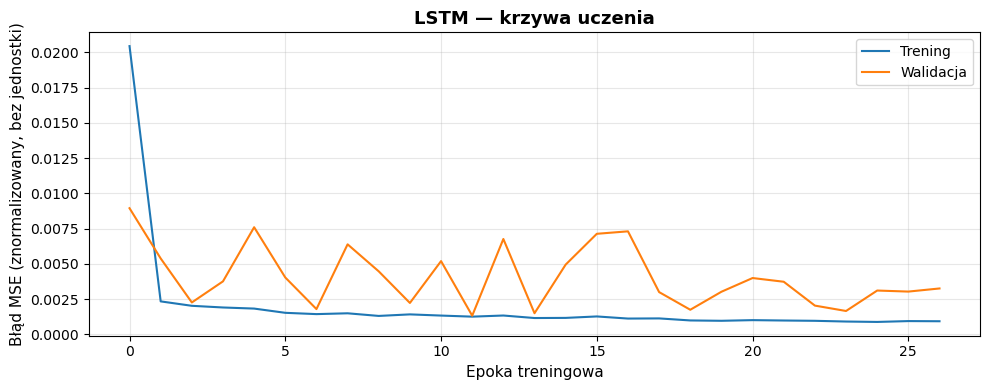

✓ Model LSTM wytrenowany.


In [118]:
import re, io
def print_polish_summary(model):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    summary_string = stream.getvalue()

    layer_names = {
        'dense':               'Gęsta',
        'dropout':             'Dropout',
        'lstm':                'LSTM',
        'bidirectional':       'Dwukierunkowy',
        'batch_normalization': 'Normalizacja wsadowa',
        'flatten':             'Spłaszczenie',
        'activation':          'Aktywacja',
        'input':               'Wejście',
    }

    def shorten_layer(match):
        layer_type = match.group(2).lower()
        polish = layer_names.get(layer_type, match.group(2))
        return f'{polish:<{len(match.group(0))}}'

    # ── 1. najpierw regex (nagłówek jeszcze po angielsku — nie zostanie tknięty) ──
    summary_string = re.sub(r'(\w+)\s*\((\w+)\)', shorten_layer, summary_string)

    # ── 2. potem tłumaczenie nagłówków ────────────────────────────────────────────
    translations = {
        "type         ":          "Warstwa (typ)",
        "Output Shape   ":        "Kształt wyjścia",
        "  Param #":              "Parametry",
        "Total params:":          "Suma parametrów:        ",
        "Trainable params:":      "Parametry trenowalne:   ",
        "Non-trainable params:":  "Parametry nietrenowalne:",
    }
    for eng, pol in translations.items():
        summary_string = summary_string.replace(eng, pol)

    print(summary_string)

def build_lstm(window, units=64):
    m = Sequential([
        LSTM(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(0.2),
        LSTM(units, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

lstm_model = build_lstm(WINDOW_LSTM)
print_polish_summary(lstm_model)

cb_lstm = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0)
]

print('\nRozpoczęto trening LSTM...')
hist_lstm = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=150, batch_size=32,
    callbacks=cb_lstm, verbose=1
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_lstm.history['loss'], label='Trening')
ax.plot(hist_lstm.history['val_loss'], label='Walidacja')
ax.set_title('LSTM — krzywa uczenia', fontweight='bold')
ax.set_xlabel('Epoka treningowa')
ax.set_ylabel('Błąd MSE (znormalizowany, bez jednostki)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('✓ Model LSTM wytrenowany.')

## 6. Model BiLSTM (Bidirectional LSTM)

**BiLSTM** przetwarza sekwencję wejściową w **dwóch kierunkach**:
- **Forward LSTM:** od najstarszej do najnowszej obserwacji (jak zwykły LSTM)
- **Backward LSTM:** od najnowszej do najstarszej

Połączone wyjścia obu kierunków dają bogatszą reprezentację wzorców w danych treningowych.

W fazie *prognozowania przyszłości* BiLSTM działa identycznie jak LSTM
 — korzysta wyłącznie z danych historycznych. Dwukierunkowość pomaga podczas treningu,
 wzbogacając gradienty o kontekst "przyszłości" w sekwencji treningowej.

Model: "sequential_26"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Warstwa (typ)                   ┃ Kształt wyjścia        ┃     Parametry ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_10                │ (None, 60, 128)        │        33,792 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout                         │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout                         │ (None, 64)             │             0 │
├─────────────────────────────────┼──────────────────

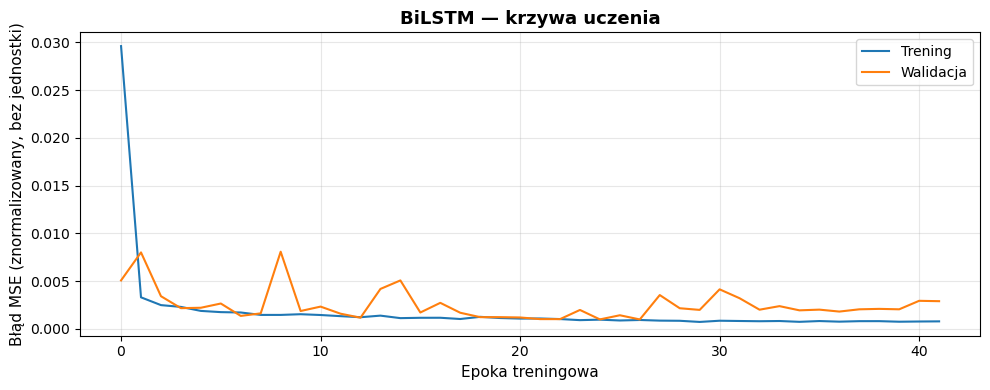

✓ Model BiLSTM wytrenowany.


In [119]:
def build_bilstm(window, units=64):
    m = Sequential([
        Bidirectional(LSTM(units, return_sequences=True), input_shape=(window, 1)),
        Dropout(0.2),
        Bidirectional(LSTM(units // 2, return_sequences=False)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

bilstm_model = build_bilstm(WINDOW_LSTM)
print_polish_summary(bilstm_model)

cb_bi = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0)
]

print('\nRozpoczęto trening BiLSTM...')
hist_bilstm = bilstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=150, batch_size=32,
    callbacks=cb_bi, verbose=1
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_bilstm.history['loss'], label='Trening')
ax.plot(hist_bilstm.history['val_loss'], label='Walidacja')
ax.set_title('BiLSTM — krzywa uczenia', fontweight='bold')
ax.set_xlabel('Epoka treningowa')
ax.set_ylabel('Błąd MSE (znormalizowany, bez jednostki)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('✓ Model BiLSTM wytrenowany.')

## 7. Prognozowanie — definicja trybów

### Tryb 2 — Czyste prognozowanie wielokrokowe *(priorytetowy)*

Od daty cięcia (2025-05-31) każdy model generuje prognozę na N dni naprzód
**bez jakiejkolwiek aktualizacji o prawdziwą cenę**.

- **ARIMA/ARIMAX:** `model.get_forecast(steps=N)` — używa własnych prognoz jako wejść dla dalszych kroków
- **LSTM/BiLSTM:** podejście *rekurencyjne* — prognozowana cena jest dodawana do bufora wejściowego dla kolejnego kroku
- **ARIMAX:** przyszłe zmienne egzogeniczne = ostatnie znane wartości (repeated)

*Naturalną własnością* ARIMA dla długich horyzontów jest stopniowe spłaszczanie do długoterminowej średniej.
LSTM/BiLSTM w trybie rekurencyjnym może dryfować.

### Tryb 1 — Walk-forward (z feedbackiem prawdziwej ceny)

Co dzień modele otrzymują **faktyczną cenę poprzedniego dnia** jako wejście.
Generuje to ciąg jednokrokowych prognoz — bardziej precyzyjnych, ale wymagających ciągłej aktualizacji.

- **ARIMA:** rozszerzenie modelu o nową obserwację (`append`, bez ponownego trenowania)
- **LSTM/BiLSTM:** bufor historii aktualizowany o prawdziwą cenę każdego dnia

In [120]:
# ─── Tryb 2: czyste prognozy wielokrokowe ────────────────────────────────────

def forecast_arima_ms(model, steps):
    fc = model.get_forecast(steps=steps)
    return fc.predicted_mean, fc.conf_int()

def forecast_arimax_ms(model, steps, last_exog):
    future_exog = np.repeat(last_exog, steps, axis=0)
    fc = model.get_forecast(steps=steps, exog=future_exog)
    return fc.predicted_mean, fc.conf_int()

def forecast_nn_recursive(nn_model, seed_scaled, steps, scaler):
    buf = list(seed_scaled[-WINDOW_LSTM:])
    out = []
    for _ in range(steps):
        x = np.array(buf[-WINDOW_LSTM:]).reshape(1, WINDOW_LSTM, 1)
        p = float(nn_model.predict(x, verbose=0)[0, 0])
        out.append(p)
        buf.append(p)
    return scaler.inverse_transform(np.array(out).reshape(-1, 1)).flatten()

# ─── Tryb 1: walk-forward (aktualiza o prawdziwa cene) ───────────────────────

def walkforward_nn(nn_model, train_prices_full, test_ser, scaler, window, n_steps):
    scaled_hist = scaler.transform(train_prices_full.values.reshape(-1, 1)).flatten()
    buf = list(scaled_hist[-window:])
    preds = []
    for true_val in test_ser.iloc[:n_steps]:
        x = np.array(buf[-window:]).reshape(1, window, 1)
        p = float(nn_model.predict(x, verbose=0)[0, 0])
        preds.append(scaler.inverse_transform([[p]])[0, 0])
        buf.append(float(scaler.transform([[true_val]])[0, 0]))
    return np.array(preds)

print('✓ Funkcje prognozowania gotowe (Tryb 1 i Tryb 2).')

✓ Funkcje prognozowania gotowe (Tryb 1 i Tryb 2).


## 8. Tryb 2 — Czyste prognozowanie wielokrokowe *(priorytetowy)*

Każdy model prognozuje N dni naprzód **z jednego punktu (2025-06-01), bez aktualizacji o prawdziwą cenę**.

**Legenda:**
- `- - -` przerywana czarna linia = prawdziwa cena (dane testowe)
- Kolorowe linie ciągłe = prognozy modeli

**Interpretacja:**
Im dłuższy horyzont, tym bardziej modele odbiegają od rzeczywistości.
ARIMA "spłaszcza się" do długoterminowej średniej. LSTM może dryfować.

In [121]:
print('Obliczanie prognoz — Tryb 2 (czyste prognozowanie wielokrokowe)...')
mode2 = {}

for label, H in HORIZONS.items():
    n = min(H, len(test_price))
    dates = test_price.index[:n]

    # ARIMA
    pred_ar, ci_ar = forecast_arima_ms(arima_model, H)
    ar_vals = (pred_ar.values if hasattr(pred_ar, 'values') else np.array(pred_ar))[:n]

    # ARIMAX
    pred_ax, ci_ax = forecast_arimax_ms(arimax_model, H, last_exog_row)
    ax_vals = (pred_ax.values if hasattr(pred_ax, 'values') else np.array(pred_ax))[:n]

    # Confidence intervals (ARIMA — dla pierwszego horyzontu do wykresu)
    ci_ar_lo = (ci_ar.iloc[:, 0].values if hasattr(ci_ar, 'iloc') else ci_ar[:, 0])[:n]
    ci_ar_hi = (ci_ar.iloc[:, 1].values if hasattr(ci_ar, 'iloc') else ci_ar[:, 1])[:n]

    # LSTM
    ls_vals = forecast_nn_recursive(lstm_model,   train_scaled_flat, n, scaler_lstm)

    # BiLSTM
    bi_vals = forecast_nn_recursive(bilstm_model, train_scaled_flat, n, scaler_lstm)

    mode2[label] = {
        'dates':  dates,
        'true':   test_price.values[:n],
        'ARIMA':  ar_vals,
        'ARIMAX': ax_vals,
        'LSTM':   ls_vals,
        'BiLSTM': bi_vals,
        'ci_ar_lo': ci_ar_lo,
        'ci_ar_hi': ci_ar_hi,
    }
    print(f'  [{label}] → {n} dni prognoz obliczonych')

print('✓ Tryb 2 — wszystkie prognozy obliczone.')

Obliczanie prognoz — Tryb 2 (czyste prognozowanie wielokrokowe)...
  [1 tydzien] → 7 dni prognoz obliczonych
  [1 miesiac] → 30 dni prognoz obliczonych
  [1 kwartal] → 90 dni prognoz obliczonych
  [2 kwartaly] → 180 dni prognoz obliczonych
  [1 rok] → 339 dni prognoz obliczonych
✓ Tryb 2 — wszystkie prognozy obliczone.


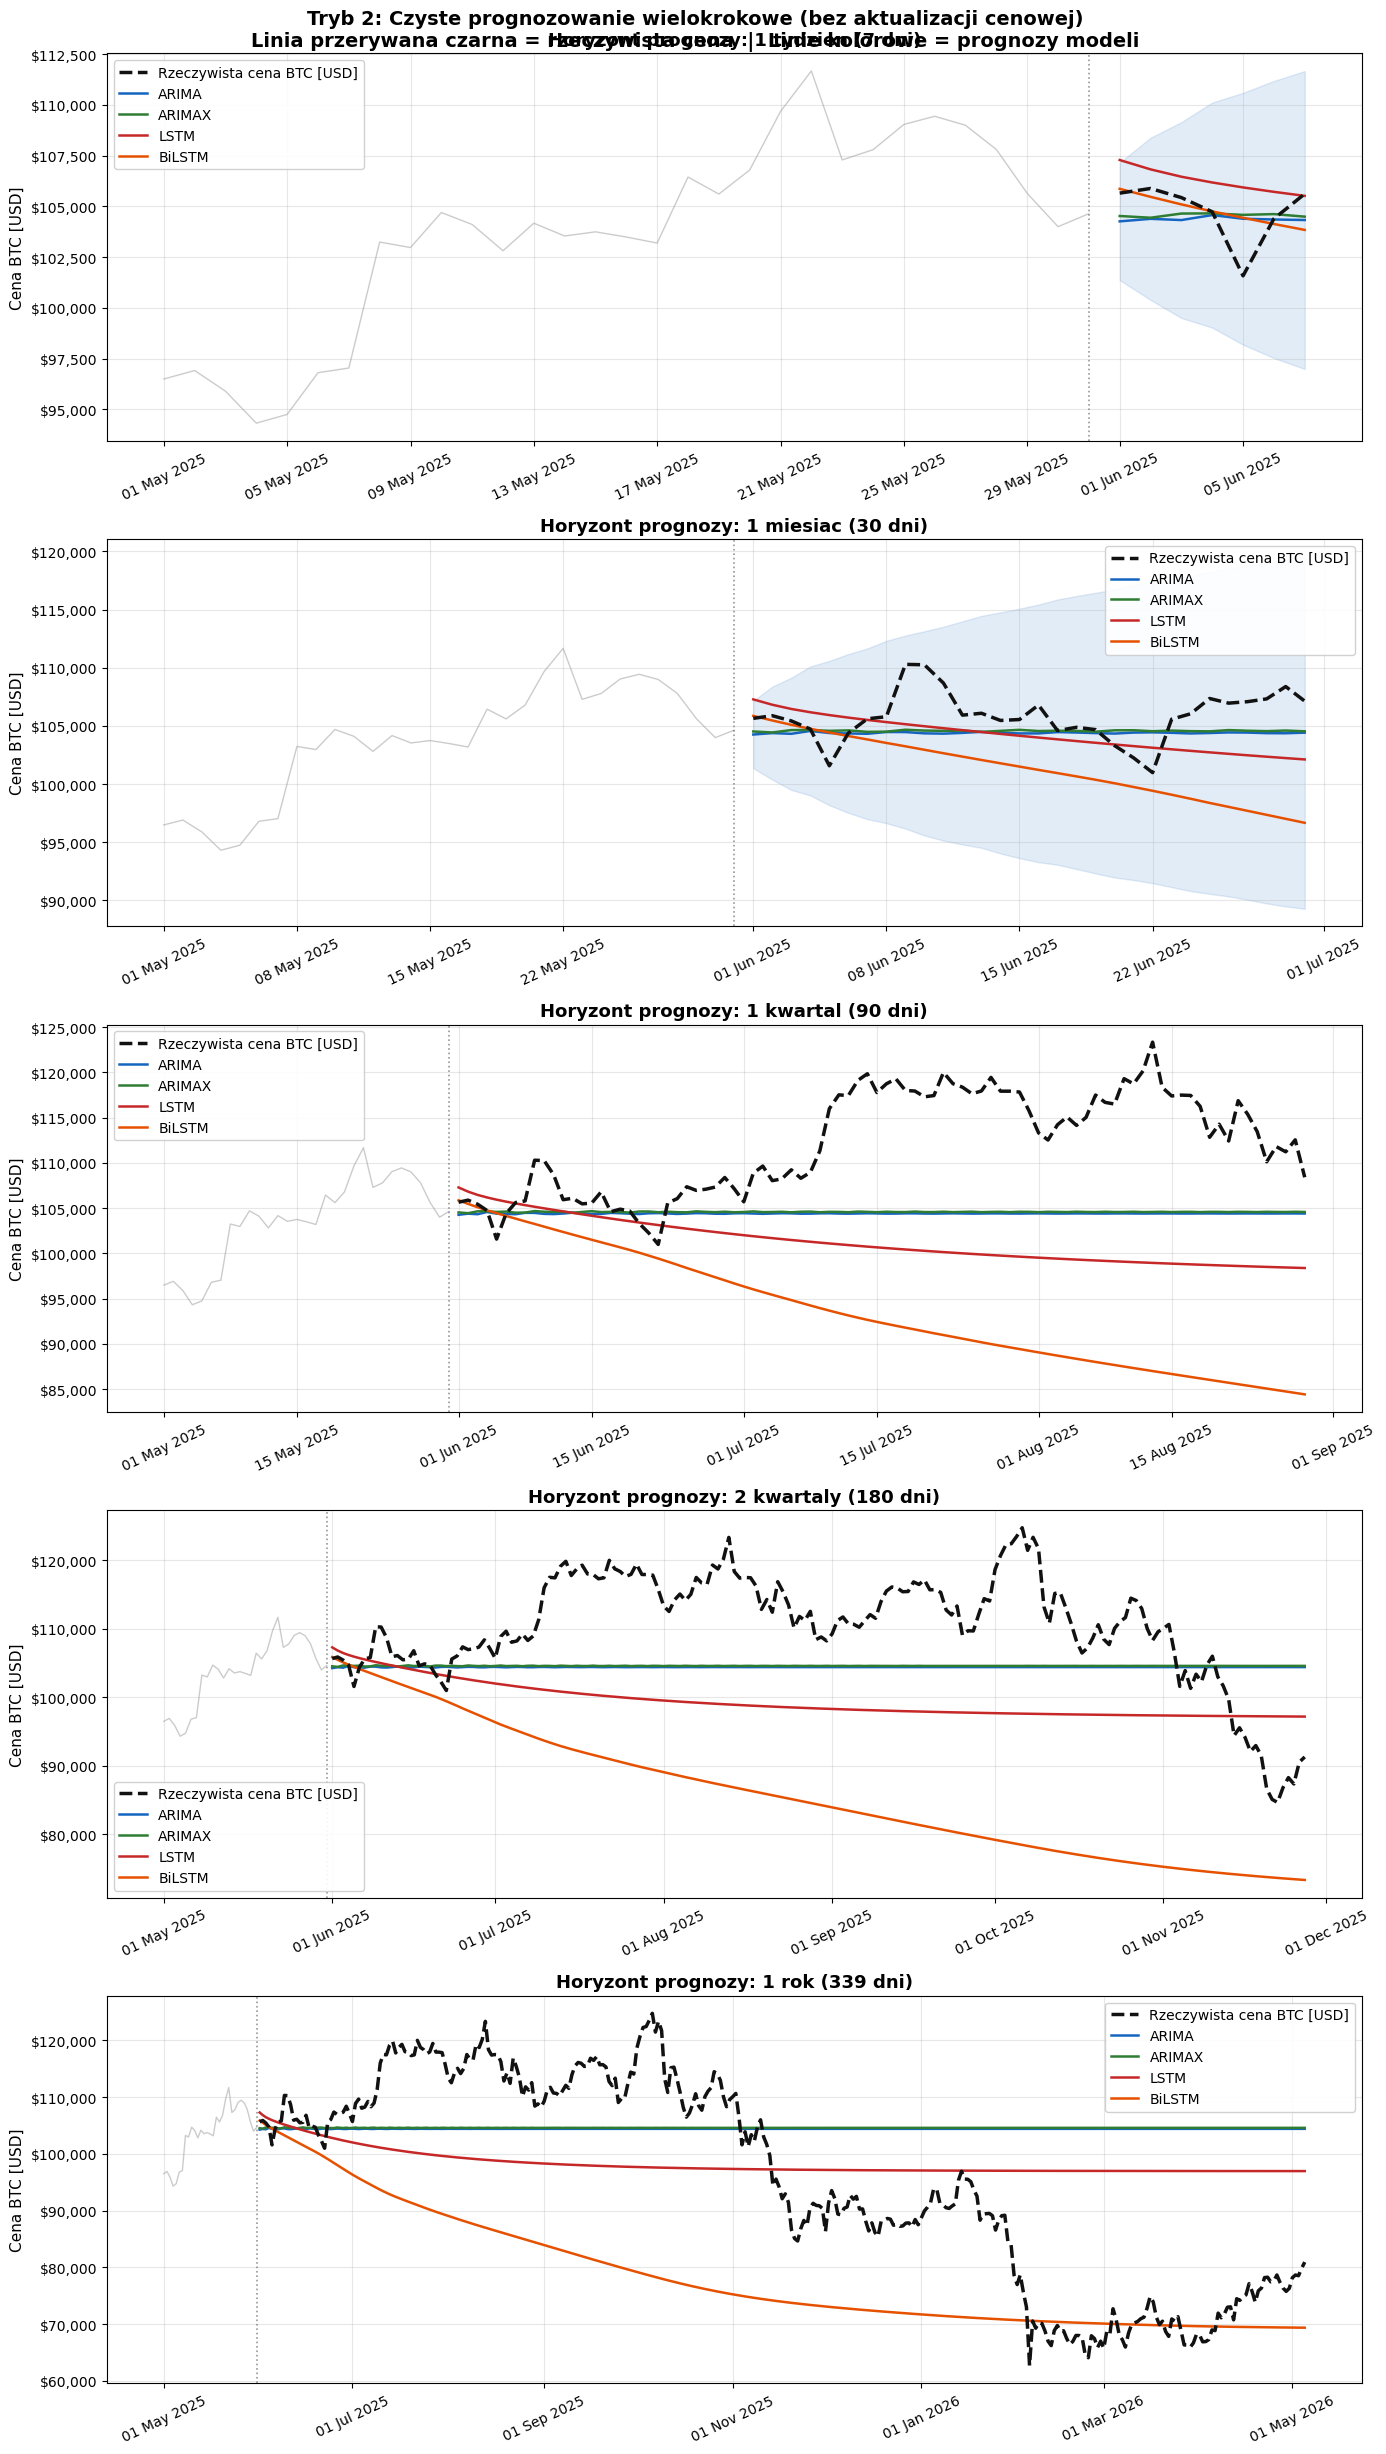

✓ Wykres Tryb 2 zapisany: data/processed/mode2_all_horizons.png


In [122]:
CONTEXT = 30  # dni kontekstu treningowego przed punktem ciecia

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 5 * len(HORIZONS)))
fig.suptitle(
    'Tryb 2: Czyste prognozowanie wielokrokowe (bez aktualizacji cenowej)\n'
    'Linia przerywana czarna = rzeczywista cena  |  Linie kolorowe = prognozy modeli',
    fontsize=14, fontweight='bold'
)

for ax, (label, H) in zip(axes, HORIZONS.items()):
    d = mode2[label]

    # Kontekst treningowy
    ctx = train_price[train_price.index >= (TRAIN_END - pd.Timedelta(days=CONTEXT))]
    ax.plot(ctx.index, ctx.values, color='#999', lw=1.0, alpha=0.5)
    ax.axvline(TRAIN_END, color='#555', ls=':', lw=1.2, alpha=0.6)

    # Prawdziwa cena
    ax.plot(d['dates'], d['true'], color=MODEL_COLORS['True'],
            lw=2.5, ls='--', label='Rzeczywista cena BTC [USD]', zorder=7)

    # Przedzial ufnosci ARIMA (opcjonalnie dla krotkiego horyzontu)
    if H <= 30:
        ax.fill_between(d['dates'], d['ci_ar_lo'], d['ci_ar_hi'],
                        color=MODEL_COLORS['ARIMA'], alpha=0.12)

    # Prognozy modeli
    for mn in ['ARIMA', 'ARIMAX', 'LSTM', 'BiLSTM']:
        ax.plot(d['dates'], d[mn], color=MODEL_COLORS[mn], lw=1.8, label=mn, zorder=5)

    ax.set_title(f'Horyzont prognozy: {label} ({len(d["dates"])} dni)', fontweight='bold')
    ax.set_ylabel('Cena BTC [USD]')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('../data/processed/mode2_all_horizons.png', bbox_inches='tight', dpi=120)
plt.show()
print('✓ Wykres Tryb 2 zapisany: data/processed/mode2_all_horizons.png')

### Metryki błędów prognozowania — Tryb 2

| Metryka | Pełna nazwa | Interpretacja |
|---------|-------------|---------------|
| **MAE ($)** | Mean Absolute Error — Średni błąd bezwzględny | Średnia różnica (w dolarach) między prognozą a prawdziwą ceną. Interpretacja: „model myli się średnio o X dolarów". |
| **RMSE ($)** | Root Mean Squared Error — Pierwiastek z błędu kwadratowego | Podobny do MAE, lecz mocniej karze za duże błędy. Jeśli RMSE >> MAE, model czasem mocno się myli. |
| **MAPE (%)** | Mean Absolute Percentage Error — Średni błąd procentowy | Błąd w procentach, niezależny od aktualnego poziomu ceny BTC. Umożliwia porównanie między różnymi latami i rynkami. |

In [123]:
rows = []
for label in HORIZONS:
    d = mode2[label]
    tv = d['true']
    for mn in ['ARIMA', 'ARIMAX', 'LSTM', 'BiLSTM']:
        pv = d[mn]
        n = min(len(tv), len(pv))
        t, p = tv[:n], pv[:n]
        mae  = mean_absolute_error(t, p)
        rmse = np.sqrt(mean_squared_error(t, p))
        mape = float(np.mean(np.abs((t - p) / (np.abs(t) + 1e-8)))) * 100
        
        rows.append({'Horyzont': label, 'Model': mn,
                     'MAE': f'{mae:,.0f}',
                     'RMSE': f'{rmse:,.0f}',
                     'MAPE': f'{mape:.1f}%'})

err_df = pd.DataFrame(rows)

i
for hor in HORIZONS:
    subset = err_df[err_df['Horyzont'] == hor]
    print(f'\n── Horyzont: {hor} ──')
    # Dodano wyrównanie do prawej (justify='right')
    print(subset[['Model', 'MAE', 'RMSE', 'MAPE']].to_string(index=False, justify='right'))


── Horyzont: 1 tydzien ──
 Model   MAE  RMSE MAPE
 ARIMA 1,185 1,464 1.1%
ARIMAX 1,113 1,430 1.1%
  LSTM 1,547 1,980 1.5%
BiLSTM   839 1,295 0.8%

── Horyzont: 1 miesiac ──
 Model   MAE  RMSE MAPE
 ARIMA 2,058 2,545 1.9%
ARIMAX 1,947 2,442 1.8%
  LSTM 2,523 3,096 2.4%
BiLSTM 4,726 5,765 4.4%

── Horyzont: 1 kwartal ──
 Model    MAE   RMSE  MAPE
 ARIMA  7,961  9,569  6.9%
ARIMAX  7,807  9,426  6.7%
  LSTM 11,183 13,261  9.7%
BiLSTM 18,683 21,717 16.2%

── Horyzont: 2 kwartaly ──
 Model    MAE   RMSE  MAPE
 ARIMA  8,460  9,953  7.6%
ARIMAX  8,337  9,848  7.5%
  LSTM 12,151 13,803 10.7%
BiLSTM 24,640 27,099 22.0%

── Horyzont: 1 rok ──
 Model    MAE   RMSE  MAPE
 ARIMA 16,521 20,174 20.3%
ARIMAX 16,539 20,253 20.4%
  LSTM 15,018 17,410 17.5%
BiLSTM 17,531 21,425 16.9%


## 9. Tryb 1 — Walk-forward z feedbackiem prawdziwej ceny

W tym trybie co dzień modele otrzymują **faktyczną cenę BTC** z poprzedniego dnia.
Generuje to sekwencję jednokrokowych prognoz — model zawsze "wie, gdzie jest".

**Wykresy pokazują te same horyzonty co Tryb 2**, ale prognozy walk-forward są z natury
dokładniejsze — żadna informacja o przyszłości nie jest potrzebna, ponieważ prognozy są
generowane dzień po dniu z aktualnymi danymi.

**Różnica vs Tryb 2:** W Trybie 2 ARIMA dla długich horyzontów drastycznie spłaszcza się
do średniej. W Trybie 1 ARIMA prognozuje zawsze jeden krok naprzód (z prawdziwego kontekstu),
więc pozostaje blisko rzeczywistości.

### Metryki błędów prognozowania — Tryb 1

Te same metryki co w Trybie 2, obliczane na prognozach **jednokrokowych** (co dzień model dostaje prawdziwą cenę z poprzedniego dnia):

| Metryka | Pełna nazwa | Interpretacja |
|---------|-------------|---------------|
| **MAE ($)** | Mean Absolute Error — Średni błąd bezwzględny | Średnia odległość prognozy od prawdziwej ceny w dolarach. Im mniejsza, tym lepiej. |
| **RMSE ($)** | Root Mean Squared Error — Pierwiastek z błędu kwadratowego | Karze silniej za rzadkie, duże błędy niż MAE. Wysoki RMSE przy niskim MAE = model sporadycznie mocno się myli. |
| **MAPE (%)** | Mean Absolute Percentage Error — Średni błąd procentowy | Błąd w %, niezależny od bieżącego poziomu ceny BTC — umożliwia porównanie między horyzontami. |

> **Tryb 1 vs Tryb 2:** Tryb 1 daje zawsze niższe błędy — model ma codzienny punkt zakotwiczenia w prawdziwej cenie, więc nie kumuluje błędu tak jak w czystym prognozowaniu wielokrokowym.

In [124]:
N_WF = min(365, len(test_price))
print(f'Obliczanie prognoz walk-forward dla {N_WF} dni testowych...')

# ─── LSTM walk-forward ────────────────────────────────────────────────────────
print('  LSTM — prognozowanie walk-forward...')
wf_lstm = walkforward_nn(lstm_model,   train_price, test_price, scaler_lstm, WINDOW_LSTM, N_WF)

print('  BiLSTM — prognozowanie walk-forward...')
wf_bilstm = walkforward_nn(bilstm_model, train_price, test_price, scaler_lstm, WINDOW_LSTM, N_WF)

# ─── ARIMA walk-forward (append bez refit) ───────────────────────────────────
print('  ARIMA — prognozowanie walk-forward...')
wf_arima_preds = []
try:
    ar_wf = arima_model
    for i, obs in enumerate(test_price.iloc[:N_WF]):
        fc = ar_wf.forecast(1)
        wf_arima_preds.append(float(fc.iloc[0]))
        ar_wf = ar_wf.append([obs], refit=False)
        if (i + 1) % 50 == 0:
            print(f'  ARIMA: {i+1}/{N_WF}', end='\r')
    print(f'  ✓ ARIMA — {len(wf_arima_preds)} kroków jednokrokowych obliczonych')
except Exception as e:
    print(f'  ⚠ Przełączenie na fallback (ponowne dopasowanie co 30 dni): {e}')
    history = list(train_price)
    ar_m = None
    for i, obs in enumerate(test_price.iloc[:N_WF]):
        try:
            if i % 30 == 0:
                ar_m = ARIMA(history, order=best_order).fit()
            wf_arima_preds.append(float(ar_m.forecast(1).iloc[0]))
        except Exception:
            wf_arima_preds.append(np.nan)
        history.append(float(obs))
        if (i + 1) % 50 == 0:
            print(f'  ARIMA: {i+1}/{N_WF}', end='\r')

# ─── ARIMAX walk-forward ──────────────────────────────────────────────────────
print('\n  ARIMAX — prognozowanie walk-forward...')
wf_arimax_preds = []
try:
    # Exog dla testu: shift(1) -> dla dnia T uzywamy exog z dnia T-1
    test_exog_raw = test[EXOG_COLS].copy()
    # Pierwszy dzien testu: uzywamy ostatniego dnia treningu
    combined_exog = pd.concat([train[EXOG_COLS].iloc[[-1]], test_exog_raw.iloc[:N_WF-1]])
    combined_exog.index = test.index[:N_WF]
    test_exog_wf = pd.DataFrame(
        scaler_exog.transform(combined_exog),
        columns=EXOG_COLS, index=combined_exog.index
    )
    ax_wf = arimax_model
    for i, (obs, exog_row) in enumerate(
        zip(test_price.iloc[:N_WF], test_exog_wf.itertuples(index=False))
    ):
        exog_arr = np.array(list(exog_row)).reshape(1, -1)
        fc = ax_wf.forecast(1, exog=exog_arr)
        wf_arimax_preds.append(float(fc.iloc[0]))
        ax_wf = ax_wf.append([obs], exog=exog_arr, refit=False)
        if (i + 1) % 50 == 0:
            print(f'  ARIMAX: {i+1}/{N_WF}', end='\r')
    print(f'  ✓ ARIMAX — {len(wf_arimax_preds)} kroków jednokrokowych obliczonych')
except Exception as e:
    print(f'  ✗ Błąd ARIMAX walk-forward: {e}')
    wf_arimax_preds = list(wf_arima_preds)  # proxy fallback

wf_dates = test_price.index[:N_WF]
wf_true  = test_price.values[:N_WF]
print('✓ Prognozowanie walk-forward zakończone.')

Obliczanie prognoz walk-forward dla 339 dni testowych...
  LSTM — prognozowanie walk-forward...
  BiLSTM — prognozowanie walk-forward...
  ARIMA — prognozowanie walk-forward...
  ✓ ARIMA — 339 kroków jednokrokowych obliczonych

  ARIMAX — prognozowanie walk-forward...
  ✓ ARIMAX — 339 kroków jednokrokowych obliczonych
✓ Prognozowanie walk-forward zakończone.


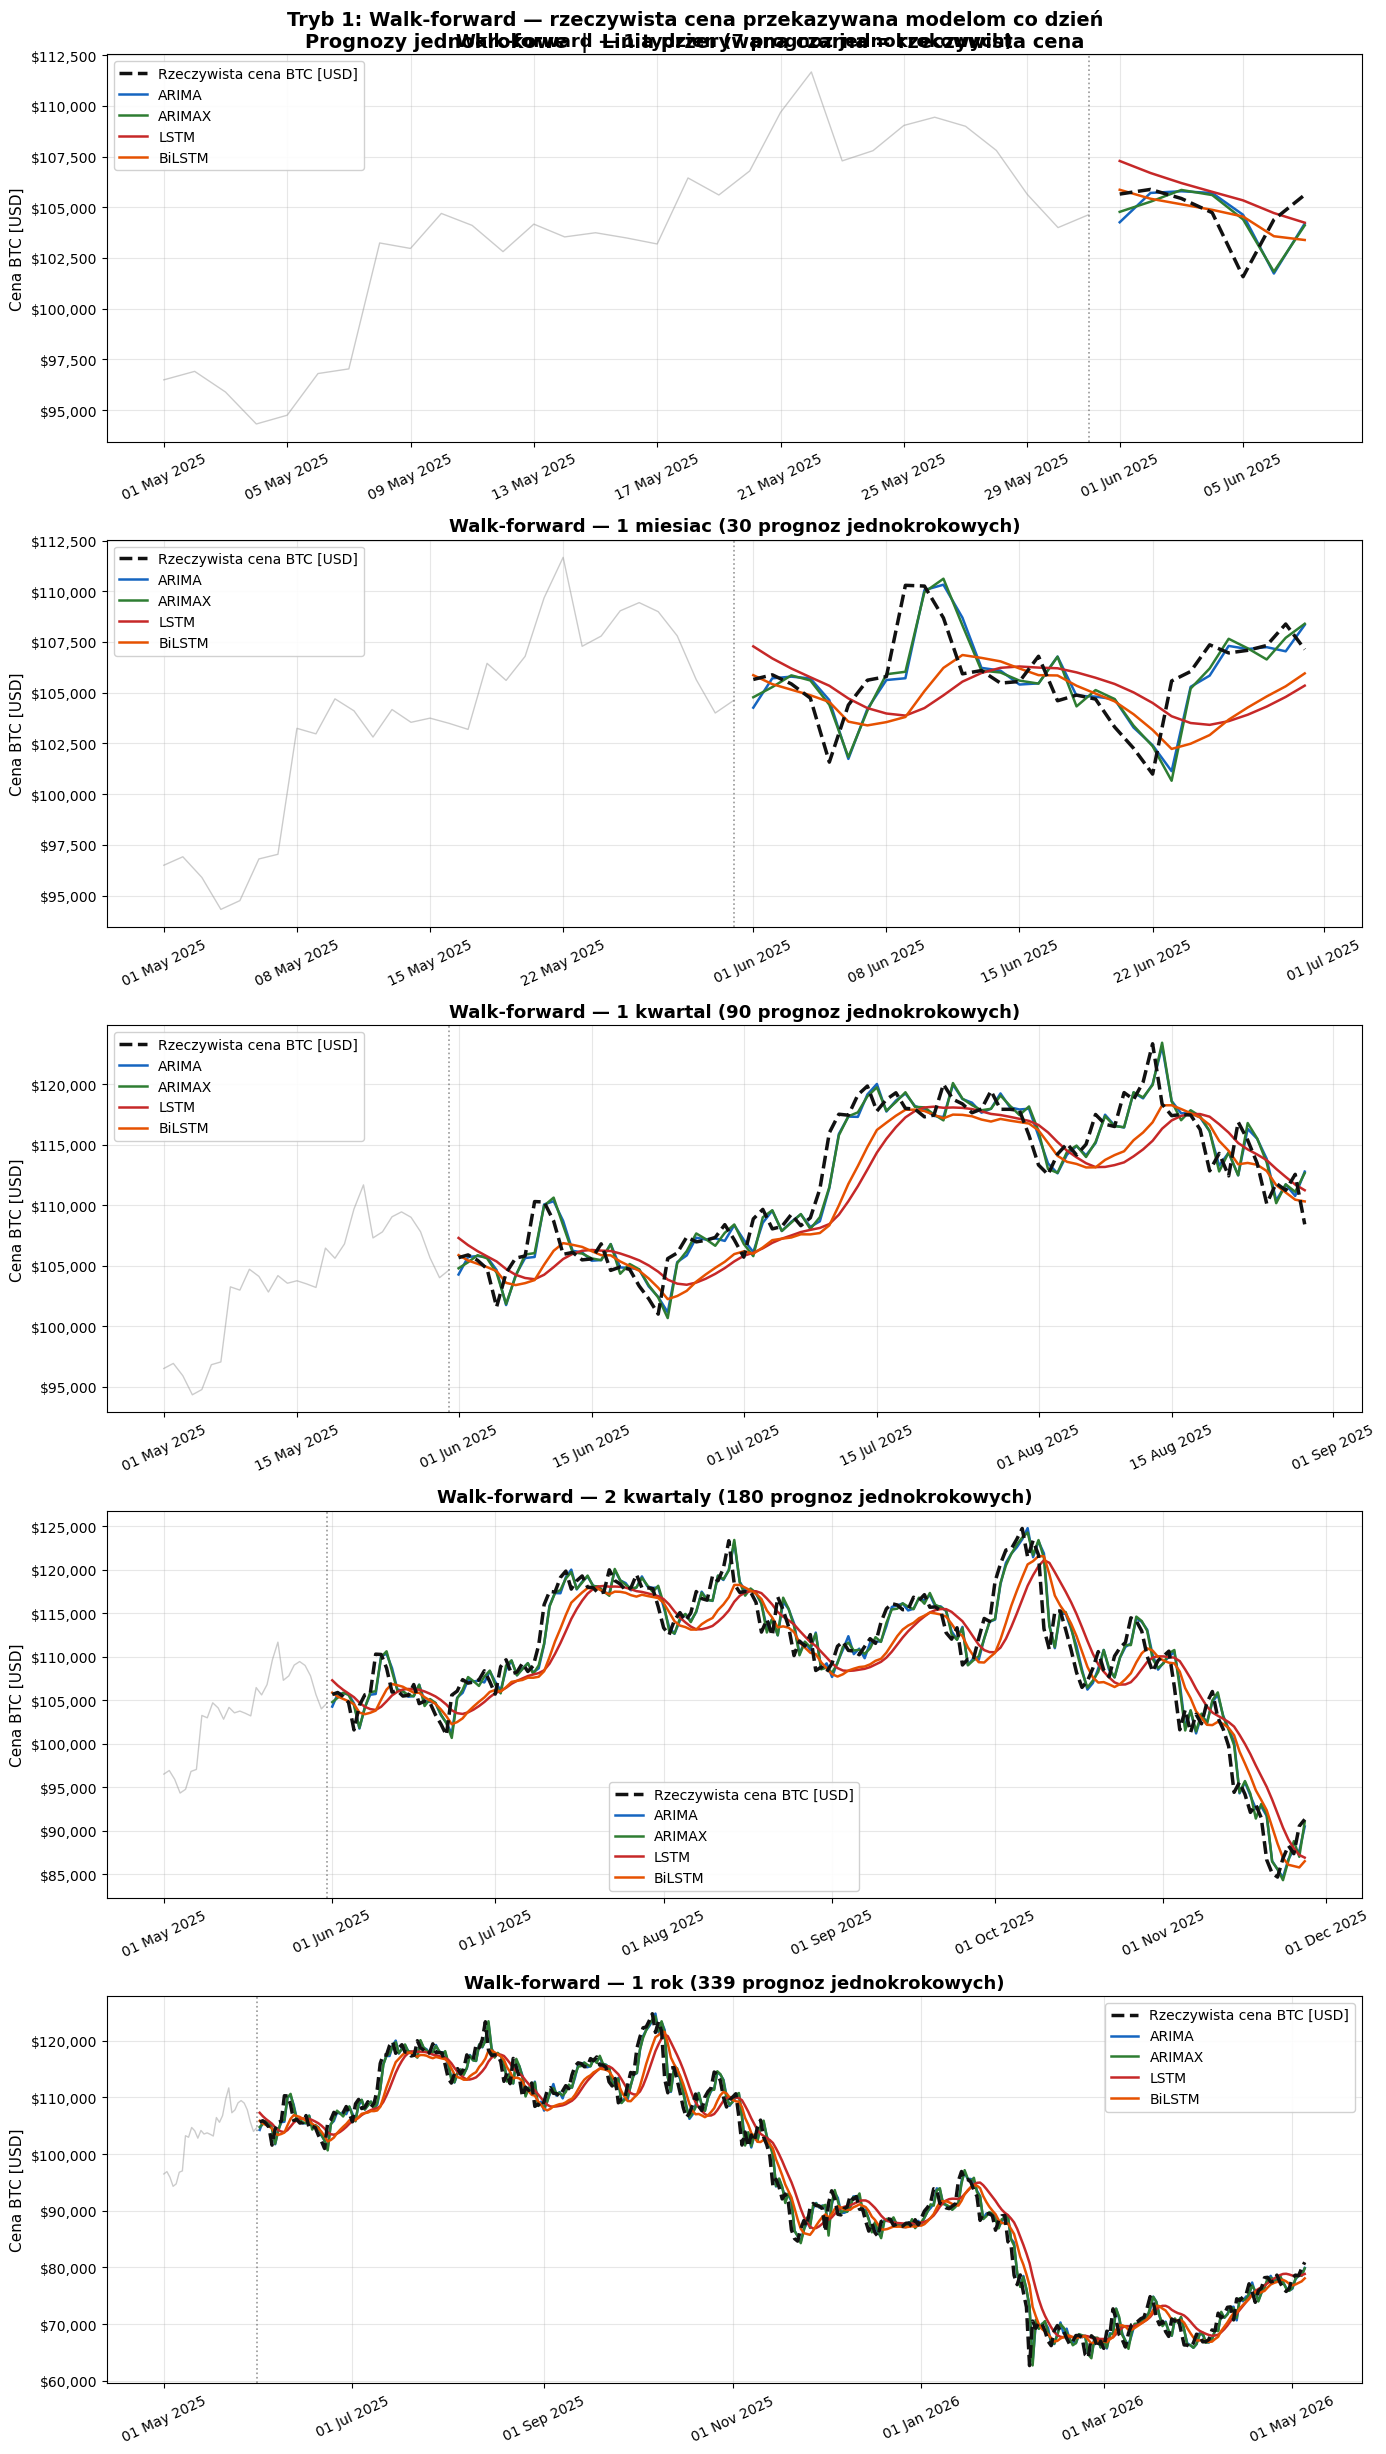

✓ Wykres Tryb 1 zapisany: data/processed/mode1_walkforward.png


In [125]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 5 * len(HORIZONS)))
fig.suptitle(
    'Tryb 1: Walk-forward — rzeczywista cena przekazywana modelom co dzień\n'
    'Prognozy jednokrokowe  |  Linia przerywana czarna = rzeczywista cena',
    fontsize=14, fontweight='bold'
)

for ax, (label, H) in zip(axes, HORIZONS.items()):
    n = min(H, N_WF, len(test_price))
    dates = wf_dates[:n]

    # Kontekst treningowy
    ctx = train_price[train_price.index >= (TRAIN_END - pd.Timedelta(days=CONTEXT))]
    ax.plot(ctx.index, ctx.values, color='#999', lw=1.0, alpha=0.5)
    ax.axvline(TRAIN_END, color='#555', ls=':', lw=1.2, alpha=0.6)

    # Prawdziwa cena
    ax.plot(dates, wf_true[:n], color=MODEL_COLORS['True'],
            lw=2.5, ls='--', label='Rzeczywista cena BTC [USD]', zorder=7)

    # Prognozy walk-forward
    ax.plot(dates, np.array(wf_arima_preds)[:n],  color=MODEL_COLORS['ARIMA'],  lw=1.8, label='ARIMA')
    ax.plot(dates, np.array(wf_arimax_preds)[:n], color=MODEL_COLORS['ARIMAX'], lw=1.8, label='ARIMAX')
    ax.plot(dates, wf_lstm[:n],                    color=MODEL_COLORS['LSTM'],   lw=1.8, label='LSTM')
    ax.plot(dates, wf_bilstm[:n],                  color=MODEL_COLORS['BiLSTM'], lw=1.8, label='BiLSTM')

    ax.set_title(f'Walk-forward — {label} ({n} prognoz jednokrokowych)', fontweight='bold')
    ax.set_ylabel('Cena BTC [USD]')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('../data/processed/mode1_walkforward.png', bbox_inches='tight', dpi=120)
plt.show()
print('✓ Wykres Tryb 1 zapisany: data/processed/mode1_walkforward.png')

In [126]:
rows1 = []
wf_preds_dict = {
    'ARIMA':  np.array(wf_arima_preds),
    'ARIMAX': np.array(wf_arimax_preds),
    'LSTM':   wf_lstm,
    'BiLSTM': wf_bilstm,
}
for label, H in HORIZONS.items():
    n = min(H, N_WF)
    tv = wf_true[:n]
    for mn, preds in wf_preds_dict.items():
        pv = preds[:n]
        valid = ~np.isnan(pv)
        if valid.sum() == 0:
            continue
        mae  = mean_absolute_error(tv[valid], pv[valid])
        rmse = np.sqrt(mean_squared_error(tv[valid], pv[valid]))
        mape = float(np.mean(np.abs((tv[valid] - pv[valid]) / (np.abs(tv[valid]) + 1e-8)))) * 100
        
        # Zmieniono formatowanie: usunięto ręczne spacje i skrócono nazwy kluczy
        rows1.append({'Horyzont': label, 'Model': mn,
                      'MAE': f'{mae:,.0f}',
                      'RMSE': f'{rmse:,.0f}',
                      'MAPE': f'{mape:.1f}%'})

err1_df = pd.DataFrame(rows1)

print('Metryki bledow — Tryb 1: walk-forward (aktualizacja prawdziwa cena co dzien)')
print('=' * 75)

for hor in HORIZONS:
    subset = err1_df[err1_df['Horyzont'] == hor]
    if len(subset) == 0:
        continue
    print(f'\n── Horyzont: {hor} ──')
    # Dodano parametry ułatwiające równe wyświetlanie tabeli
    print(subset[['Model', 'MAE', 'RMSE', 'MAPE']].to_string(index=False, justify='right'))

Metryki bledow — Tryb 1: walk-forward (aktualizacja prawdziwa cena co dzien)

── Horyzont: 1 tydzien ──
 Model   MAE  RMSE MAPE
 ARIMA 1,432 1,750 1.4%
ARIMAX 1,382 1,644 1.3%
  LSTM 1,385 1,737 1.3%
BiLSTM 1,016 1,454 1.0%

── Horyzont: 1 miesiac ──
 Model   MAE  RMSE MAPE
 ARIMA 1,251 1,740 1.2%
ARIMAX 1,267 1,716 1.2%
  LSTM 2,188 2,702 2.1%
BiLSTM 1,968 2,512 1.8%

── Horyzont: 1 kwartal ──
 Model   MAE  RMSE MAPE
 ARIMA 1,407 1,855 1.3%
ARIMAX 1,421 1,856 1.3%
  LSTM 2,340 3,111 2.1%
BiLSTM 2,063 2,729 1.8%

── Horyzont: 2 kwartaly ──
 Model   MAE  RMSE MAPE
 ARIMA 1,566 2,057 1.4%
ARIMAX 1,567 2,034 1.4%
  LSTM 3,088 3,959 2.8%
BiLSTM 2,531 3,247 2.3%

── Horyzont: 1 rok ──
 Model   MAE  RMSE MAPE
 ARIMA 1,477 2,018 1.6%
ARIMAX 1,496 2,026 1.6%
  LSTM 2,736 3,673 2.9%
BiLSTM 2,218 2,925 2.4%


## 10. Miesięczne średnie — kwartał i pół roku (Tryb 2)

Zamiast porównywać codzienne wartości, patrzymy na **miesięczne średnie cen**.

Każda kropka to średnia cena BTC w danym miesiącu:
- **Czarna przerywana + kropki** = prawdziwa średnia miesięczna
- **Kolorowe linie + kropki** = średnia miesięczna prognoz danego modelu

Ten rodzaj wykresu jest bardziej "odporny" na szumy dzienne i lepiej pokazuje,
czy modele trafnie odgadują **ogólny trend** w horyzoncie kwartalnym i półrocznym.

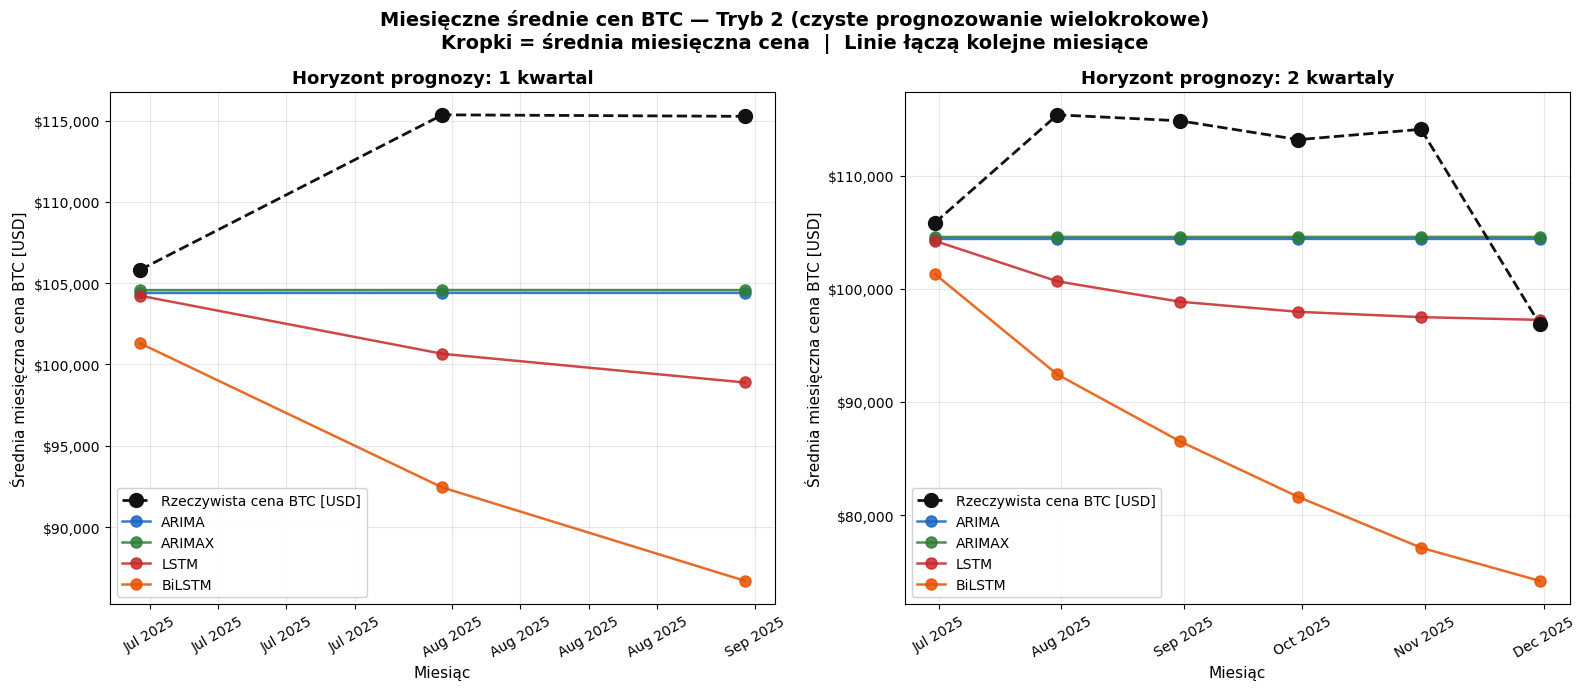

✓ Wykres miesięcznych średnich zapisany: data/processed/monthly_avg_comparison.png


In [127]:
quarterly_horizons = {k: v for k, v in HORIZONS.items() if v in [90, 180]}

if len(quarterly_horizons) < 2:
    # fallback: use the two middle horizons
    h_items = list(HORIZONS.items())
    quarterly_horizons = dict(h_items[2:4])

fig, axes = plt.subplots(1, len(quarterly_horizons), figsize=(8 * len(quarterly_horizons), 7))
if len(quarterly_horizons) == 1:
    axes = [axes]
fig.suptitle(
    'Miesięczne średnie cen BTC — Tryb 2 (czyste prognozowanie wielokrokowe)\n'
    'Kropki = średnia miesięczna cena  |  Linie łączą kolejne miesiące',
    fontsize=14, fontweight='bold'
)

for ax, (label, H) in zip(axes, quarterly_horizons.items()):
    d = mode2[label]
    n = len(d['dates'])

    true_ser = pd.Series(d['true'], index=d['dates'])
    true_mo  = true_ser.resample('M').mean()

    ax.plot(true_mo.index, true_mo.values, 'o--',
            color=MODEL_COLORS['True'], lw=2.0, ms=10,
            label='Rzeczywista cena BTC [USD]', zorder=7)

    for mn in ['ARIMA', 'ARIMAX', 'LSTM', 'BiLSTM']:
        pred_ser = pd.Series(d[mn][:n], index=d['dates'])
        pred_mo  = pred_ser.resample('M').mean()
        ax.plot(pred_mo.index, pred_mo.values, 'o-',
                color=MODEL_COLORS[mn], lw=1.8, ms=8, alpha=0.85, label=mn)

    ax.set_title(f'Horyzont prognozy: {label}', fontweight='bold')
    ax.set_ylabel('Średnia miesięczna cena BTC [USD]')
    ax.set_xlabel('Miesiąc')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/processed/monthly_avg_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print('✓ Wykres miesięcznych średnich zapisany: data/processed/monthly_avg_comparison.png')

In [128]:
# Zbiorcze zestawienie MAE dla obu trybow (horyzont 1 miesiac)
print('Zbiorcze zestawienie bledow — horyzont: 1 miesiac')
print('  Tryb 2 MAE = Sr. blad bezwzgl. przy czystym prognozowaniu (bez aktualizacji) [USD]')
print('  Tryb 1 MAE = Sr. blad bezwzgl. przy walk-forward (codzienna aktualizacja) [USD]')
print('  Tryb 1 jest zawsze dokladniejszy — model dostaje codzienne korekty.')
print('=' * 60)
print(f'{"Model":<10} {"Tryb 2 — MAE ($)":>24} {"Tryb 1 — MAE ($)":>24}')
print('-' * 60)

label_1m = '1 miesiac'
if label_1m in mode2:
    d = mode2[label_1m]
    n = min(30, N_WF, len(test_price))
    for mn in ['ARIMA', 'ARIMAX', 'LSTM', 'BiLSTM']:
        t2 = mean_absolute_error(d['true'], d[mn])
        pv_wf = wf_preds_dict[mn][:n]
        valid = ~np.isnan(pv_wf)
        t1 = mean_absolute_error(d['true'][:n][valid], pv_wf[valid]) if valid.sum() > 0 else float('nan')
        print(f'{mn:<10} {t2:>18,.0f} USD {t1:>16,.0f} USD')

Zbiorcze zestawienie bledow — horyzont: 1 miesiac
  Tryb 2 MAE = Sr. blad bezwzgl. przy czystym prognozowaniu (bez aktualizacji) [USD]
  Tryb 1 MAE = Sr. blad bezwzgl. przy walk-forward (codzienna aktualizacja) [USD]
  Tryb 1 jest zawsze dokladniejszy — model dostaje codzienne korekty.
Model              Tryb 2 — MAE ($)         Tryb 1 — MAE ($)
------------------------------------------------------------
ARIMA                   2,058 USD            1,251 USD
ARIMAX                  1,947 USD            1,267 USD
LSTM                    2,523 USD            2,188 USD
BiLSTM                  4,726 USD            1,968 USD


## 11b. Symulacja Monte Carlo — rozkład możliwych cen

Prognoza punktowa ARIMA zbiega do długoterminowej średniej (matematyczna własność modelu).  
**Monte Carlo** generuje N realistycznych ścieżek cenowych, uwzględniając losowość modelu — 
pokazuje *zakres* możliwych wyników, a nie tylko wartość oczekiwaną.

Każda ścieżka to symulacja z modelu ARIMA z dodanym szumem o odchyleniu standardowym równym odch. std reszt treningowych.

| Percentyl | Interpretacja |
|-----------|---------------|
| **5. – 95.** | 90% przedział możliwych wyników |
| **25. – 75.** | „Środkowe" 50% ścieżek (najbardziej prawdopodobne) |
| **Mediana (50.)** | Środkowa ścieżka — lepsza niż prognoza punktowa dla asymetrycznych rozkładów |

Symulacja Monte Carlo: 300 ścieżek × 30 dni naprzód
Odch. std reszt modelu ARIMA: 1748.00 USD


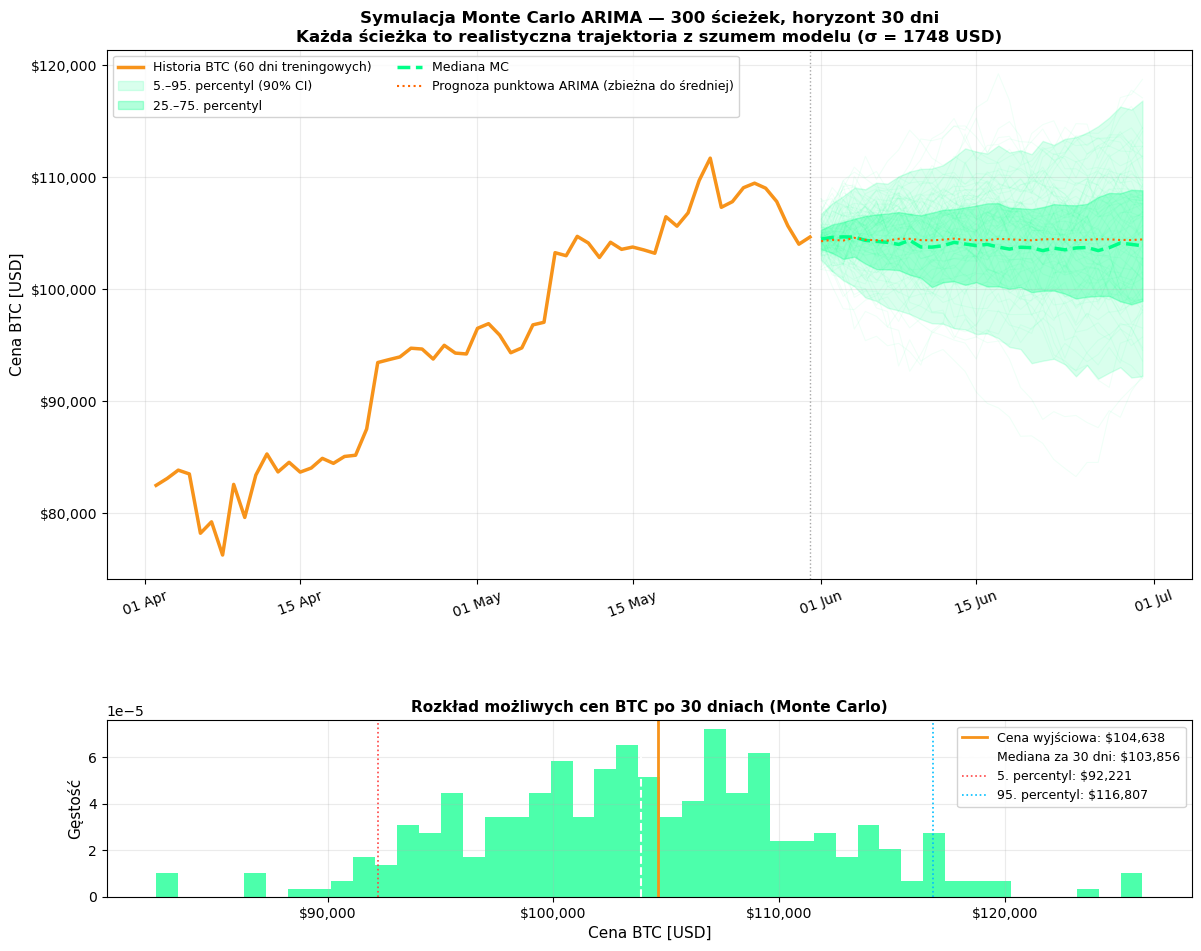


Symulacja Monte Carlo — rozkład cen za 30 dni:
  Cena wyjściowa (ostatni dzień treningu): $104,638
  Mediana:                                 $103,856
  5. percentyl  (scenariusz pesymistyczny): $92,221
  95. percentyl (scenariusz optymistyczny): $116,807
  Prawdopodobieństwo wzrostu ceny:          45.3%
  Prawdopodobieństwo wzrostu > +5%:         20.0%
  Prawdopodobieństwo spadku > −5%:          28.3%


In [129]:
# ── Symulacja Monte Carlo na modelu ARIMA ─────────────────────────────────────
N_SIMS  = 300
N_STEPS = 30   # horyzont: 30 dni naprzód
np.random.seed(42)

sigma = np.std(arima_model.resid)   # odch. std reszt modelu treningowego
last_known = train_price.copy()

print(f'Symulacja Monte Carlo: {N_SIMS} ścieżek × {N_STEPS} dni naprzód')
print(f'Odch. std reszt modelu ARIMA: {sigma:.2f} USD')

sim_paths = []
for i in range(N_SIMS):
    try:
        path = arima_model.simulate(
            nsimulations=N_STEPS,
            anchor='end',
            random_state=np.random.RandomState(i)
        ).values
    except Exception:
        # Fallback: ręczna symulacja przez różnicowanie
        last_vals = list(train_price.iloc[-20:].values)
        path = []
        for _ in range(N_STEPS):
            try:
                fc = ARIMA(last_vals, order=best_order).fit().forecast(steps=1)[0]
            except Exception:
                fc = last_vals[-1]
            noise = np.random.normal(0, sigma)
            val = fc + noise
            path.append(val)
            last_vals.append(val)
            last_vals.pop(0)
        path = np.array(path)
    sim_paths.append(path)

sim_paths  = np.array(sim_paths)   # (N_SIMS, N_STEPS)
future_mc  = pd.date_range(start=train_price.index[-1] + pd.Timedelta(days=1), periods=N_STEPS, freq='D')
last_price = float(train_price.iloc[-1])

pct_5  = np.percentile(sim_paths, 5,  axis=0)
pct_25 = np.percentile(sim_paths, 25, axis=0)
pct_50 = np.percentile(sim_paths, 50, axis=0)
pct_75 = np.percentile(sim_paths, 75, axis=0)
pct_95 = np.percentile(sim_paths, 95, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 11),
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.4})

ax1 = axes[0]

# Historia (ostatnie 60 dni treningowych)
hist_slice = train_price.iloc[-60:]
ax1.plot(hist_slice.index, hist_slice.values, color='#F7931A', lw=2.5, zorder=5,
         label='Historia BTC (60 dni treningowych)')
ax1.axvline(train_price.index[-1], color='gray', lw=1, linestyle=':', alpha=0.7)

# Losowe ścieżki MC (80 z 300 dla czytelności)
idx_sample = np.random.choice(N_SIMS, size=80, replace=False)
for i in idx_sample:
    ax1.plot(future_mc, sim_paths[i], color='#00FF88', alpha=0.06, lw=0.8)

# Pasma percentylowe
ax1.fill_between(future_mc, pct_5,  pct_95, alpha=0.15, color='#00FF88', label='5.–95. percentyl (90% CI)')
ax1.fill_between(future_mc, pct_25, pct_75, alpha=0.30, color='#00FF88', label='25.–75. percentyl')
ax1.plot(future_mc, pct_50, color='#00FF88', lw=2.5, linestyle='--', zorder=6, label='Mediana MC')

# Prognoza punktowa ARIMA (dla porównania)
arima_pt_vals = forecast_arima_ms(arima_model, N_STEPS)[0]
if hasattr(arima_pt_vals, 'values'):
    arima_pt_vals = arima_pt_vals.values
ax1.plot(future_mc, arima_pt_vals[:N_STEPS], color='#FF6600', lw=1.5,
         linestyle=':', zorder=7, label='Prognoza punktowa ARIMA (zbieżna do średniej)')

ax1.set_title(
    f'Symulacja Monte Carlo ARIMA — {N_SIMS} ścieżek, horyzont {N_STEPS} dni\n'
    f'Każda ścieżka to realistyczna trajektoria z szumem modelu (σ = {sigma:.0f} USD)',
    fontsize=12, fontweight='bold'
)
ax1.set_ylabel('Cena BTC [USD]')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.85)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.tick_params(axis='x', rotation=20)
ax1.grid(True, alpha=0.25)

# Dolny panel: rozkład cen końcowych po N_STEPS dniach
ax2 = axes[1]
final_prices = sim_paths[:, -1]
ax2.hist(final_prices, bins=45, color='#00FF88', alpha=0.7, edgecolor='none', density=True)
ax2.axvline(last_price,
            color='#F7931A', lw=2, label=f'Cena wyjściowa: ${last_price:,.0f}')
ax2.axvline(np.percentile(final_prices, 50), color='white', lw=1.5, linestyle='--',
            label=f'Mediana za {N_STEPS} dni: ${np.percentile(final_prices,50):,.0f}')
ax2.axvline(np.percentile(final_prices, 5),  color='#FF4444', lw=1.2, linestyle=':',
            label=f'5. percentyl: ${np.percentile(final_prices,5):,.0f}')
ax2.axvline(np.percentile(final_prices, 95), color='#00BFFF', lw=1.2, linestyle=':',
            label=f'95. percentyl: ${np.percentile(final_prices,95):,.0f}')
ax2.set_title(f'Rozkład możliwych cen BTC po {N_STEPS} dniach (Monte Carlo)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Cena BTC [USD]')
ax2.set_ylabel('Gęstość')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=9, framealpha=0.85)
ax2.grid(True, alpha=0.25)

plt.savefig('../data/processed/arima_montecarlo.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\nSymulacja Monte Carlo — rozkład cen za {N_STEPS} dni:')
print(f'  Cena wyjściowa (ostatni dzień treningu): ${last_price:,.0f}')
print(f'  Mediana:                                 ${np.percentile(final_prices,50):,.0f}')
print(f'  5. percentyl  (scenariusz pesymistyczny): ${np.percentile(final_prices,5):,.0f}')
print(f'  95. percentyl (scenariusz optymistyczny): ${np.percentile(final_prices,95):,.0f}')
print(f'  Prawdopodobieństwo wzrostu ceny:          {np.mean(final_prices > last_price)*100:.1f}%')
print(f'  Prawdopodobieństwo wzrostu > +5%:         {np.mean(final_prices > last_price*1.05)*100:.1f}%')
print(f'  Prawdopodobieństwo spadku > −5%:          {np.mean(final_prices < last_price*0.95)*100:.1f}%')


## 11c. Trafność kierunkowa prognoz (Directional Accuracy)

**Directional Accuracy (DA)** mierzy, jak często model poprawnie przewiduje *kierunek* zmiany ceny (wzrost vs. spadek), niezależnie od skali błędu.

- DA = 50% → model nie lepszy niż rzut monetą
- DA > 60% → model ma wartość informacyjną co do kierunku ruchu
- DA > 70% → bardzo dobry wynik dla rynków finansowych

Jest to metryka **praktycznie ważniejsza niż MAE/RMSE** dla strategii tradingowych.

Trafność kierunkowa prognoz — Tryb 2 (czyste prognozowanie wielokrokowe)
(DA = odsetek dni, w których model poprawnie przewidział wzrost lub spadek ceny)
  Benchmark: losowe zgadywanie = 50.0% — model jest wartościowy powyżej tej granicy

  ── Horyzont: 1 tydzien ──
    ARIMA     DA =  50.0%   ✗ nie lepiej niż losowo
    ARIMAX    DA =  33.3%   ✗ nie lepiej niż losowo
    LSTM      DA =  50.0%   ✗ nie lepiej niż losowo
    BiLSTM    DA =  50.0%   ✗ nie lepiej niż losowo

  ── Horyzont: 1 miesiac ──
    ARIMA     DA =  41.4%   ✗ nie lepiej niż losowo
    ARIMAX    DA =  41.4%   ✗ nie lepiej niż losowo
    LSTM      DA =  48.3%   ✗ nie lepiej niż losowo
    BiLSTM    DA =  48.3%   ✗ nie lepiej niż losowo

  ── Horyzont: 1 kwartal ──
    ARIMA     DA =  50.6%   ✓ powyżej losowego
    ARIMAX    DA =  46.1%   ✗ nie lepiej niż losowo
    LSTM      DA =  51.7%   ✓ powyżej losowego
    BiLSTM    DA =  51.7%   ✓ powyżej losowego

  ── Horyzont: 2 kwartaly ──
    ARIMA     DA =  48.6%   ✗ nie le

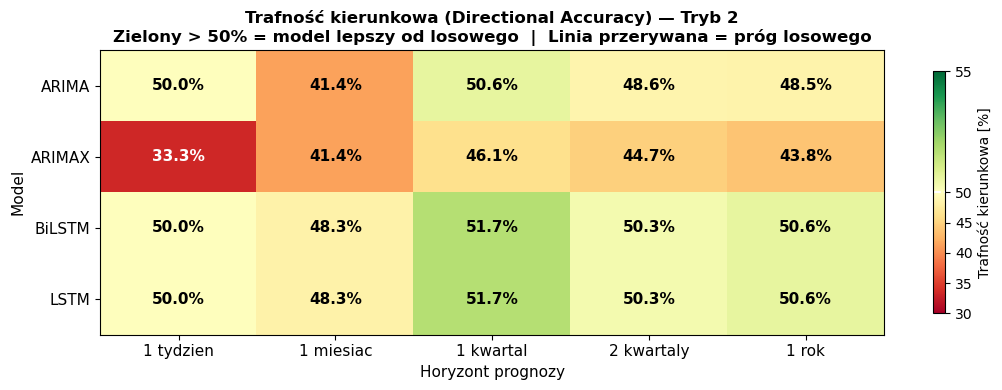

In [130]:
# ── Trafność kierunkowa (Directional Accuracy) dla wszystkich modeli ──────────

def directional_accuracy(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    actual_dir = np.sign(np.diff(a))
    pred_dir   = np.sign(np.diff(p))
    return np.mean(actual_dir == pred_dir) * 100

print('Trafność kierunkowa prognoz — Tryb 2 (czyste prognozowanie wielokrokowe)')
print('(DA = odsetek dni, w których model poprawnie przewidział wzrost lub spadek ceny)')
print('=' * 72)
print(f'  Benchmark: losowe zgadywanie = 50.0% — model jest wartościowy powyżej tej granicy')
print()

da_rows = []
for label, H in HORIZONS.items():
    d = mode2[label]
    n = min(len(d['true']), H)
    true_slice = d['true'][:n]
    print(f'  ── Horyzont: {label} ──')
    for mn in ['ARIMA', 'ARIMAX', 'LSTM', 'BiLSTM']:
        pred_slice = d[mn][:n]
        if len(pred_slice) >= 2 and len(true_slice) >= 2:
            da = directional_accuracy(true_slice, pred_slice)
            beat = '✓ powyżej losowego' if da > 50 else '✗ nie lepiej niż losowo'
            print(f'    {mn:<8}  DA = {da:5.1f}%   {beat}')
            da_rows.append({'Horyzont': label, 'Model': mn, 'DA (%)': round(da, 1)})
        else:
            print(f'    {mn:<8}  DA = brak danych')
    print()

# Wykres: heatmapa DA
if da_rows:
    da_df = pd.DataFrame(da_rows).pivot(index='Model', columns='Horyzont', values='DA (%)')
    # Upewnij się, że kolumny są w kolejności horyzontów
    da_df = da_df[[h for h in HORIZONS.keys() if h in da_df.columns]]

    from matplotlib.colors import TwoSlopeNorm as TSN
    fig, ax = plt.subplots(figsize=(11, 4))
    norm_da = TSN(vmin=30, vcenter=50, vmax=55)
    im = ax.imshow(da_df.values, cmap='RdYlGn', norm=norm_da, aspect='auto')

    ax.set_xticks(range(len(da_df.columns)))
    ax.set_yticks(range(len(da_df.index)))
    ax.set_xticklabels(da_df.columns, fontsize=11)
    ax.set_yticklabels(da_df.index, fontsize=11)

    for i in range(len(da_df.index)):
        for j in range(len(da_df.columns)):
            val = da_df.values[i, j]
            if not np.isnan(val):
                text_col = 'white' if val < 35 or val > 70 else 'black'
                ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                        fontsize=11, color=text_col, fontweight='bold')

    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label('Trafność kierunkowa [%]', fontsize=10)
    cbar.ax.axhline(50, color='white', lw=1.5, linestyle='--')

    ax.set_title('Trafność kierunkowa (Directional Accuracy) — Tryb 2\n'
                 'Zielony > 50% = model lepszy od losowego  |  Linia przerywana = próg losowego',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Horyzont prognozy')
    ax.set_ylabel('Model')
    plt.tight_layout()
    plt.savefig('../data/processed/directional_accuracy.png', bbox_inches='tight', dpi=130)
    plt.show()


## 11. Wnioski

### Obserwacje z Trybu 2 (czyste prognozowanie)
- **ARIMA** ma tendencję do powrotu do długoterminowej średniej — dla horyzontów > 1 miesiąca
  prognoza "spłaszcza się". To statystyczna własność modelu, nie błąd.
- **ARIMAX** korzysta z danych on-chain (stablecoiny, hash-rate, aktywne adresy), co może
  poprawić prognozę dla krótkich horyzontów (7–30 dni), gdy sygnały on-chain są informacyjne.
- **LSTM/BiLSTM** w trybie rekurencyjnym może dryfować — własne prognozy podawane z powrotem
  jako wejście kumulują błąd w czasie.
- Dla długich horyzontów (> 90 dni) **żaden model** nie jest wiarygodnym predyktorem
  ceny BTC — kryptorynki są zbyt zmienne.

### Obserwacje z Trybu 1 (walk-forward)
- Wszystkie modele radzą sobie znacznie lepiej niż w Trybie 2, bo co dzień dostają
  aktualny punkt zakotwiczenia.
- **LSTM/BiLSTM** w trybie walk-forward są zwykle najbardziej precyzyjne dla krótkich
  horyzontów (1–7 dni), bo wychwytują lokalne wzorce cenowe.
- **ARIMA** (i ARIMAX) są zaskakująco konkurencyjne dla 1-krokowych prognoz.

### Ogólne wnioski
1. Dane on-chain (ARIMAX) poprawiają prognozę, szczególnie przy turbulencjach rynkowych.
2. Dla krótkich horyzontów (1 tydzień) różnice między modelami są małe; dla długich — ogromne.
3. Żaden model nie przewiduje trafnie ceny BTC na rok naprzód — to oczekiwany wynik dla
   aktywów o wysokiej zmienności.

---
*Projekt: Bitcoin On-Chain Analysis | Dane: 2021–2026*